#### Bibliothèques

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

#### Chargement de la base de données et tri temporel

In [18]:
DATA_PATH = "C:/Users/jehov/Documents/Cours/UTT/9mars/data/processed/02_dataset_silver.csv"
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

display(df.head())

df.shape

,date,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
0,2000-01-01,9.1,8.0,10.3,19.0,8.4,6.1,4018600.0,1774200.0,2244400.0,...,1.723014,1.345448,0.389039,-4.1,-4.3,5.9,0.112500,0.416667,-0.050268,0
1,2000-04-01,8.7,7.6,9.9,18.0,8.0,5.8,3890000.0,1701100.0,2188900.0,...,1.754474,1.977185,3.053740,6.0,0.3,-4.3,0.720700,0.666667,-0.038337,0
2,2000-07-01,8.4,7.2,9.6,17.4,7.8,5.5,3807900.0,1659300.0,2148600.0,...,1.901287,1.861366,-4.481288,-1.1,1.4,0.3,0.474600,0.333333,-0.036859,0
3,2000-10-01,8.0,6.9,9.4,16.9,7.5,5.2,3690300.0,1601400.0,2088900.0,...,1.492307,1.966656,4.852425,1.0,-3.9,1.4,0.286567,0.000000,-0.018875,0
4,2001-01-01,7.8,6.6,9.2,16.8,7.3,4.9,3609400.0,1565300.0,2044100.0,...,1.376954,1.819251,-1.117994,-1.4,-1.1,-3.9,-0.279133,0.000000,0.036620,0


(103, 59)

#### Pré-traitement

In [21]:
# Valeurs manquantes et doublons

print("NA total:", int(df.isna().sum().sum()))
print("Dates dupliquées:", int(df["date"].duplicated().sum()))
print("Lignes dupliquées:", int(df.duplicated().sum()))

NA total: 0
Dates dupliquées: 0
Lignes dupliquées: 0


In [35]:
# Variables numériques

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Nb variables numériques:", len(num_cols))

Nb variables numériques: 58


#### EDA (plots pour chaque variable)

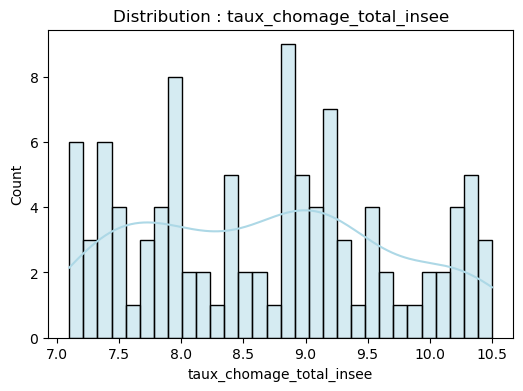

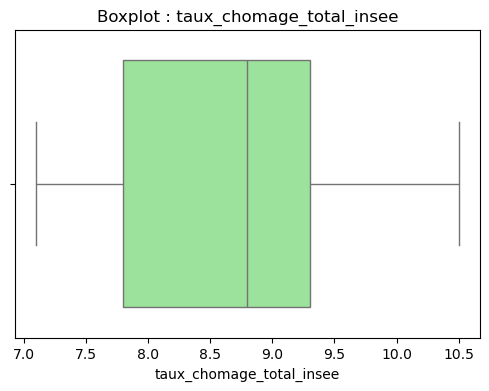

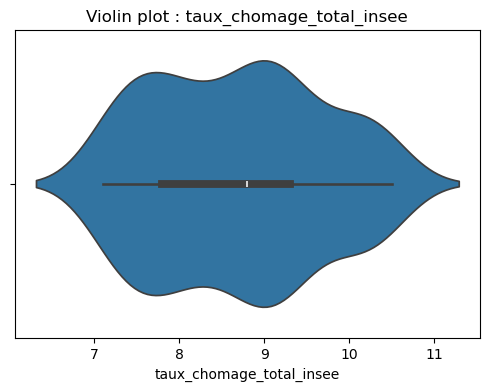

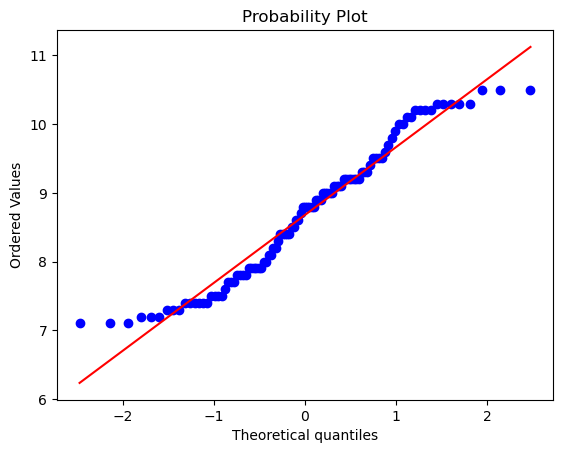

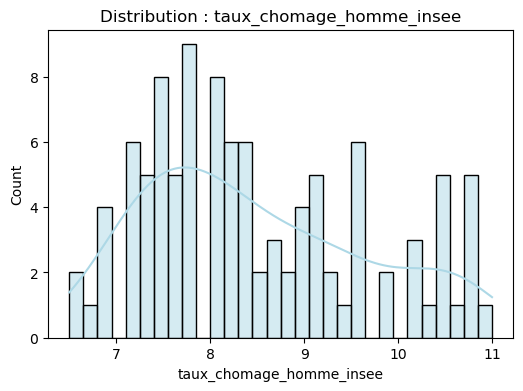

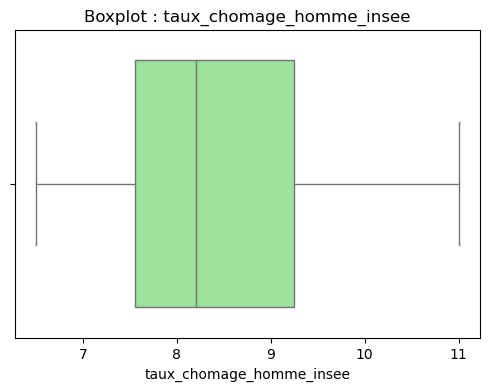

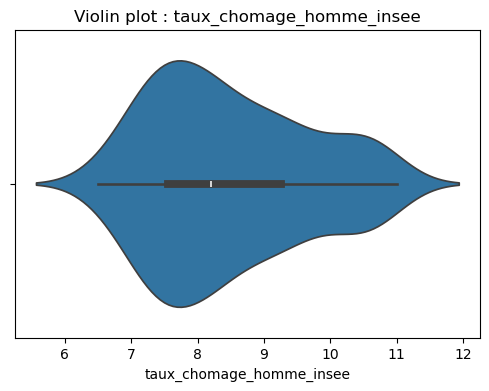

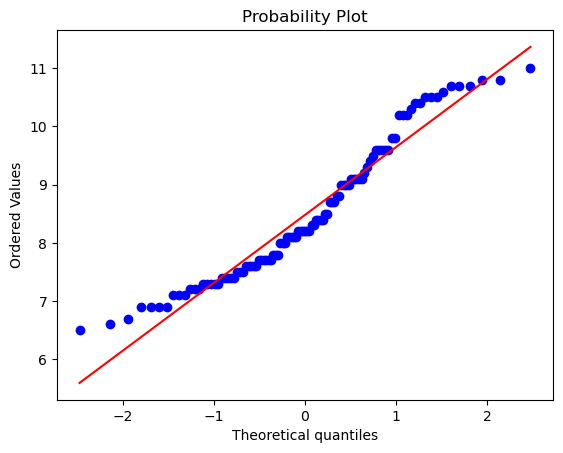

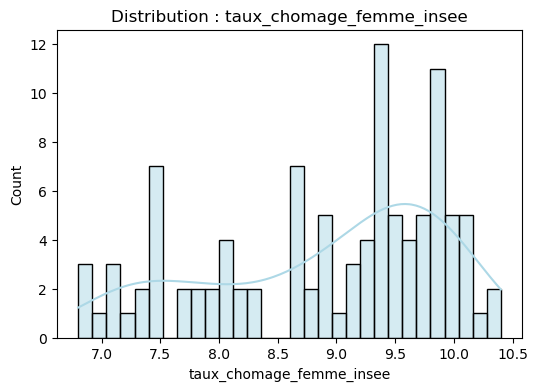

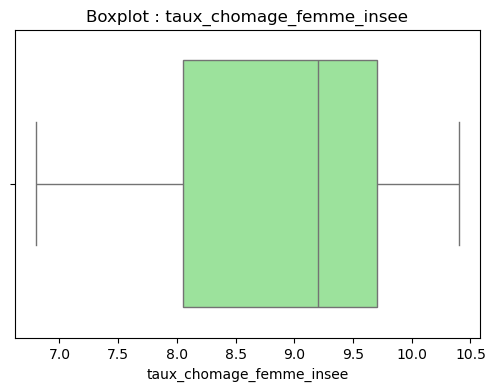

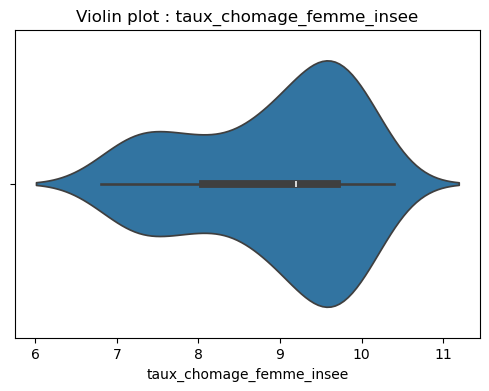

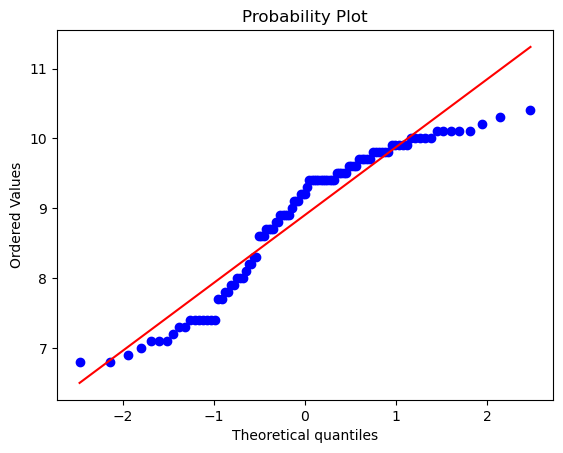

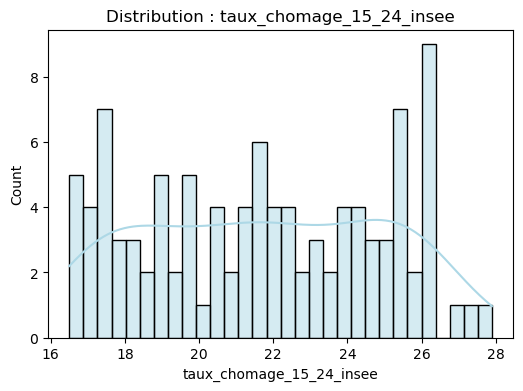

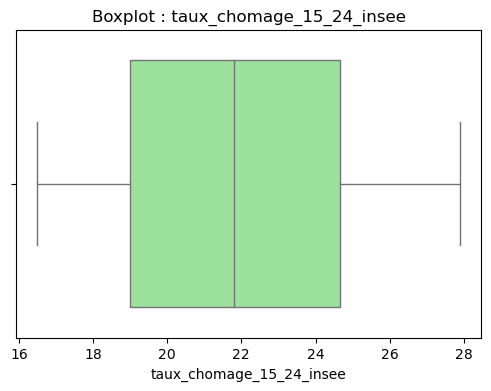

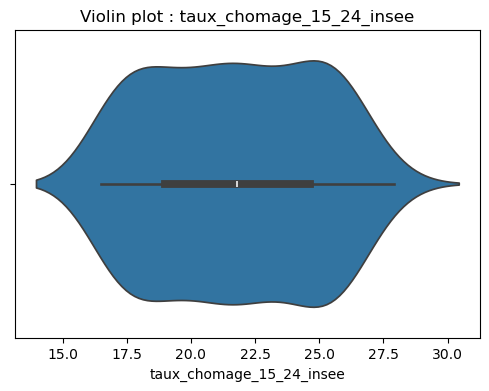

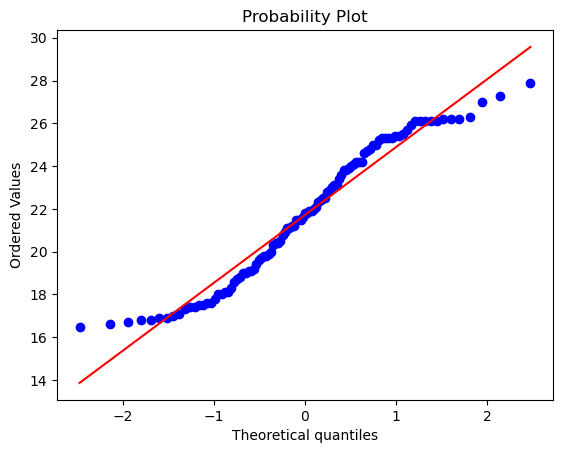

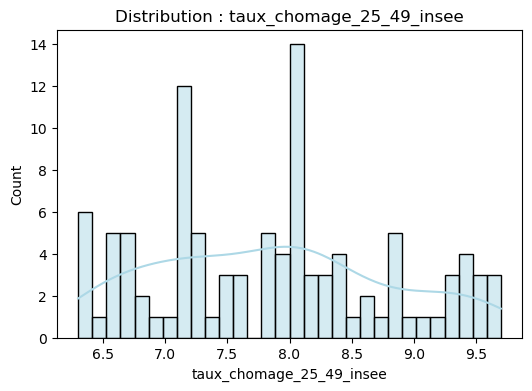

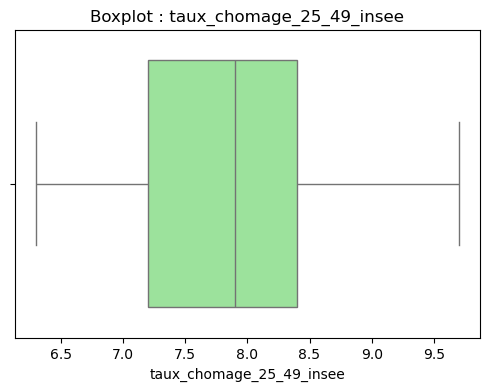

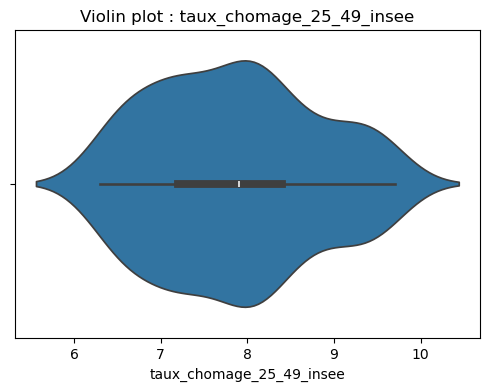

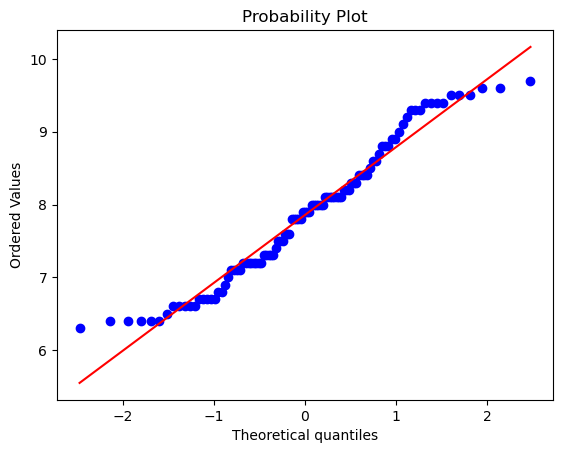

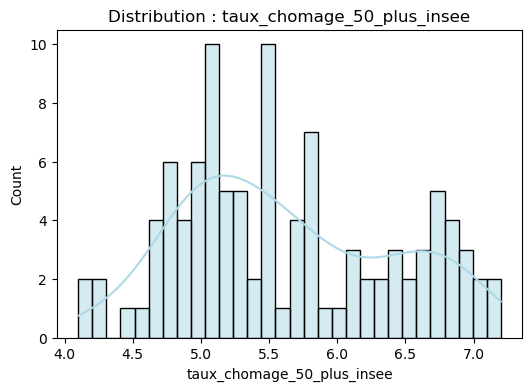

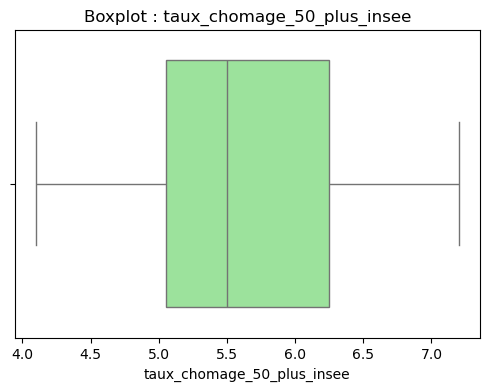

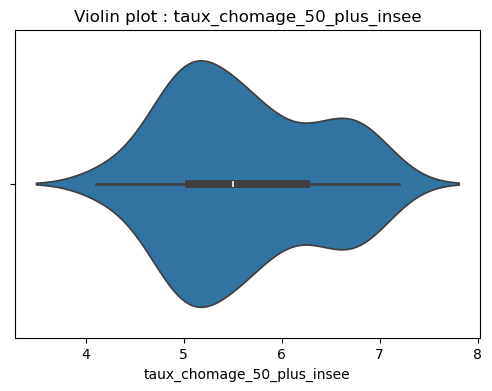

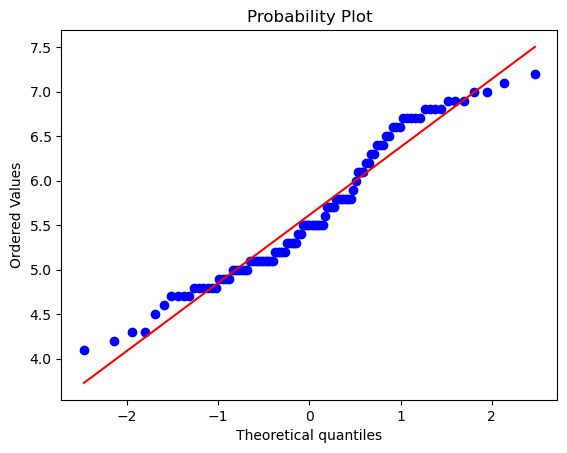

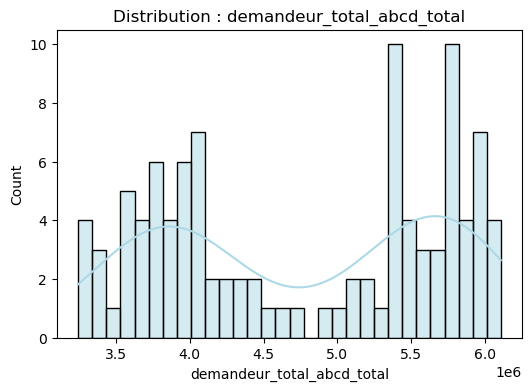

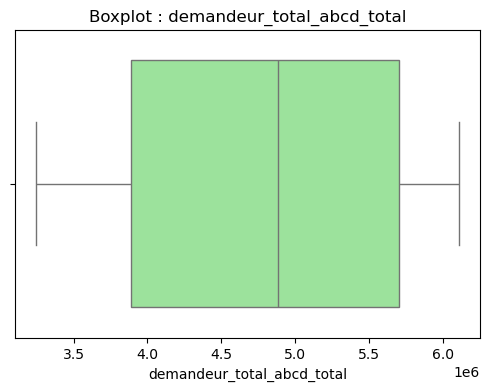

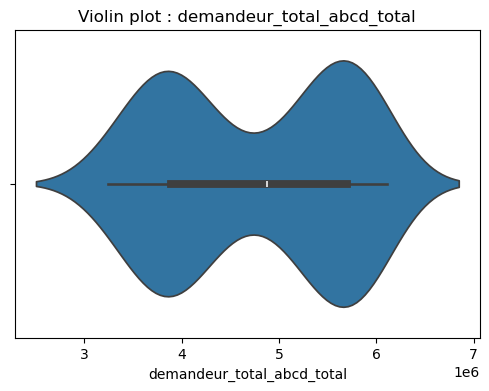

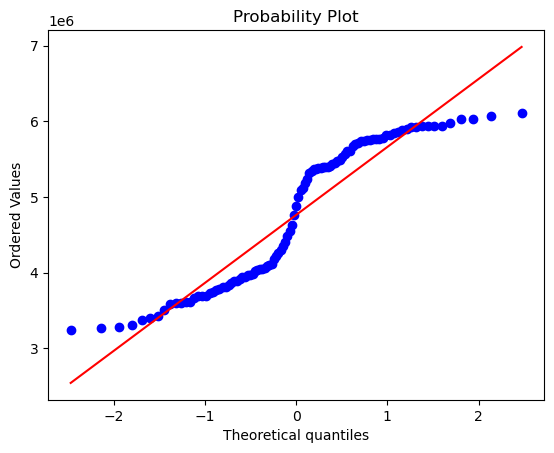

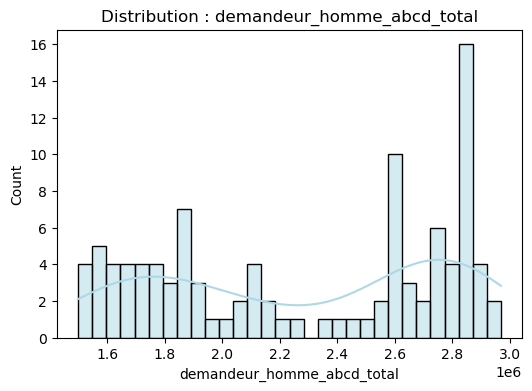

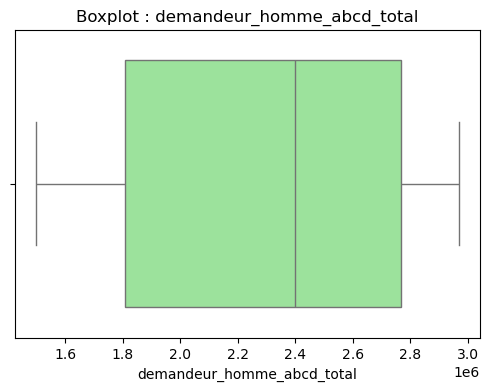

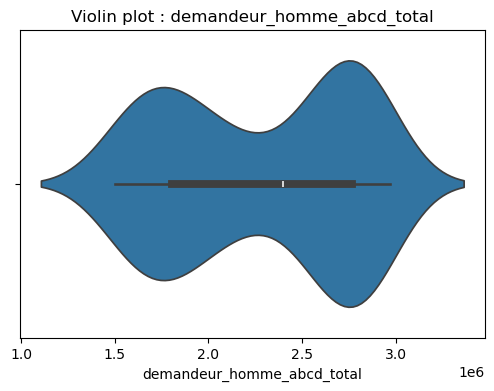

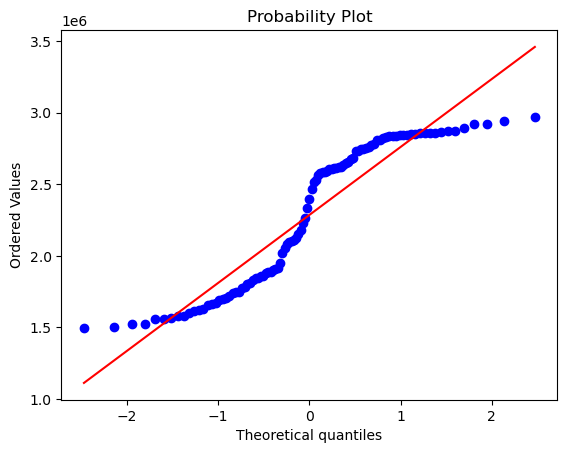

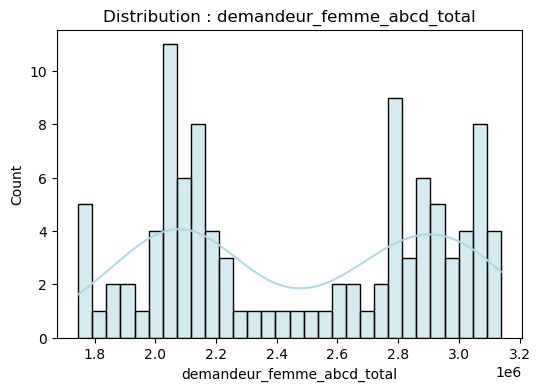

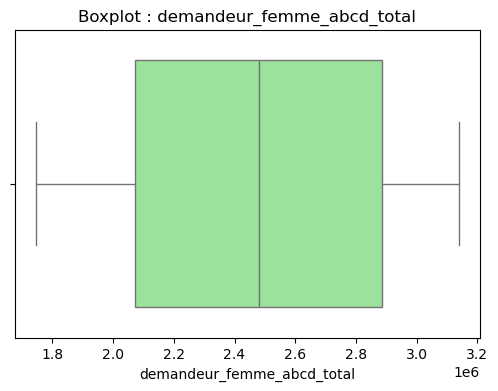

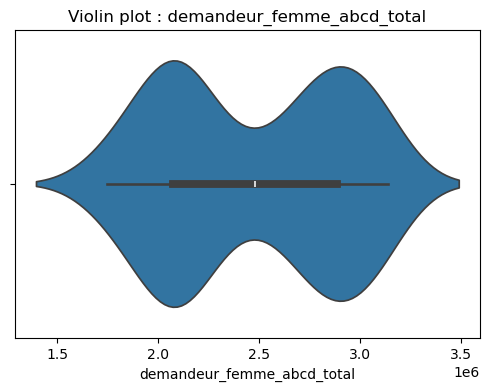

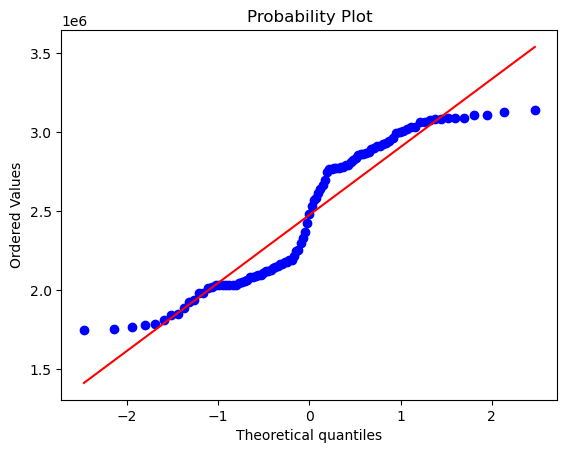

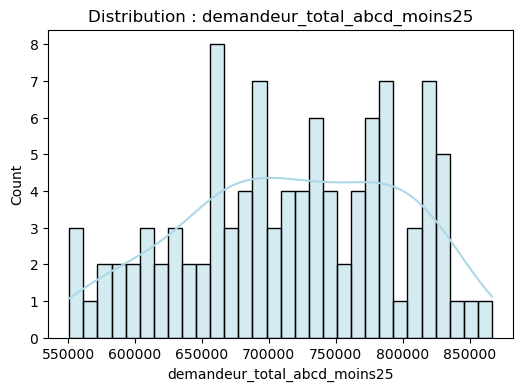

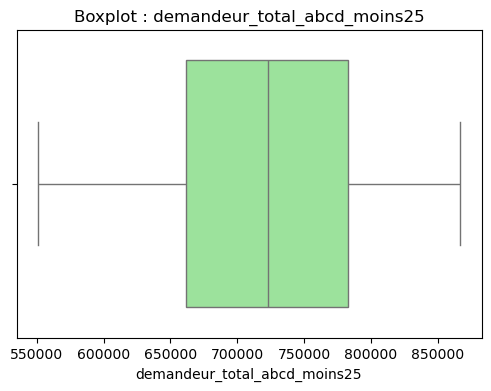

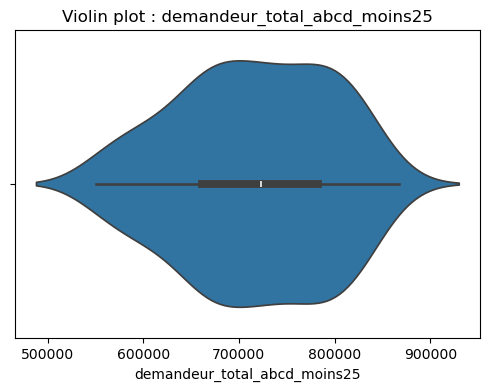

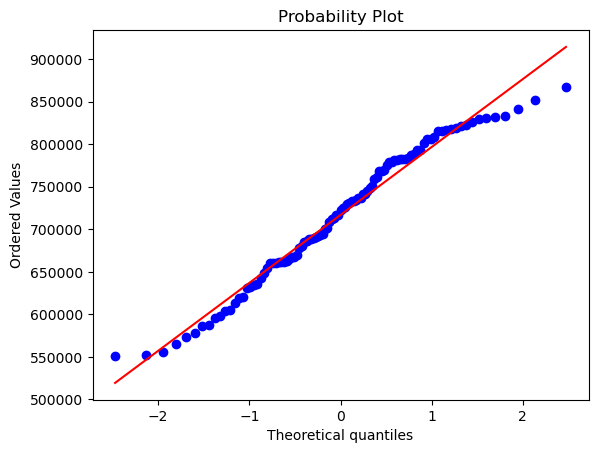

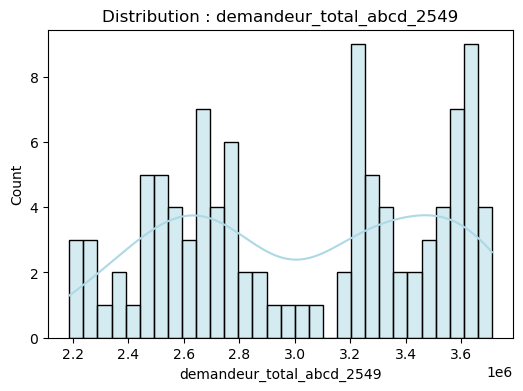

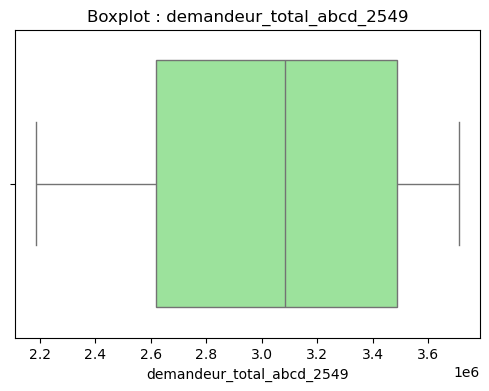

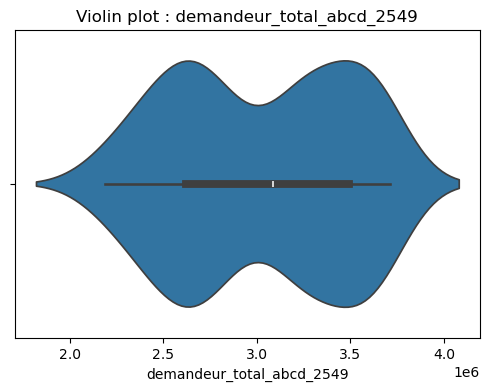

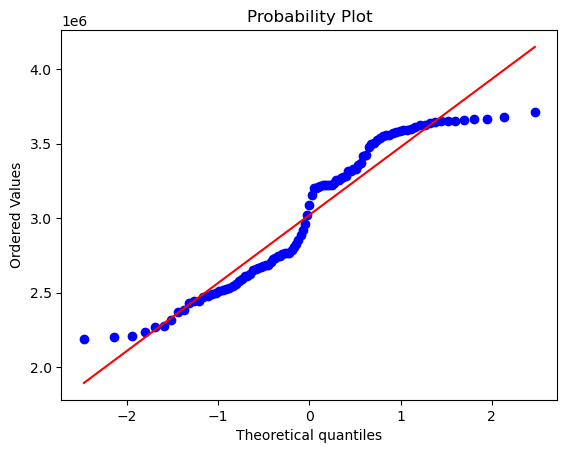

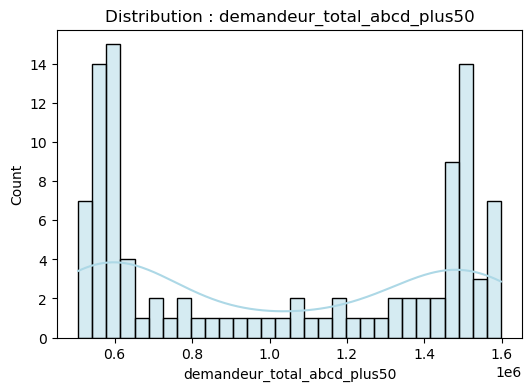

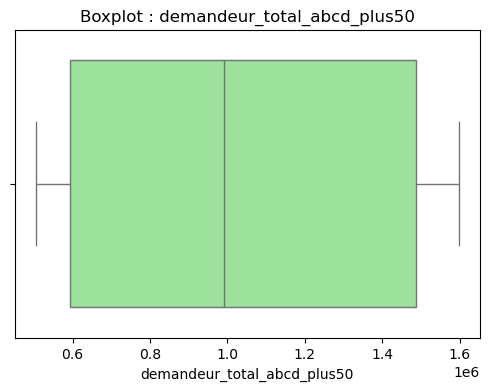

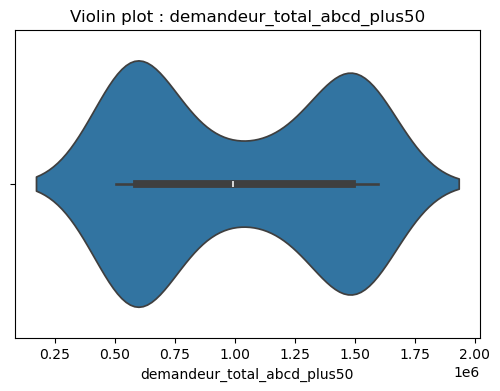

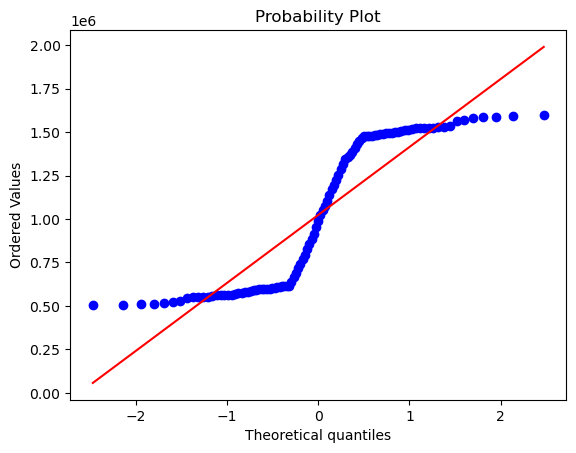

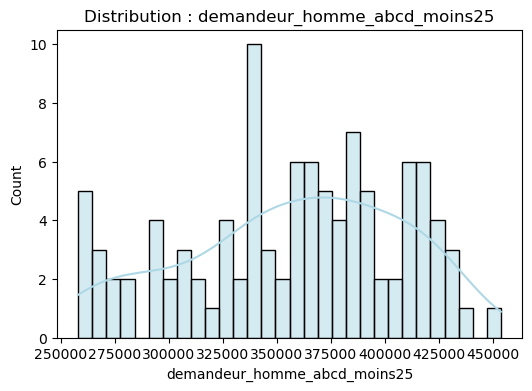

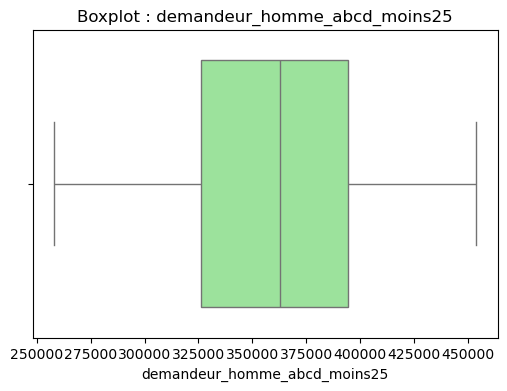

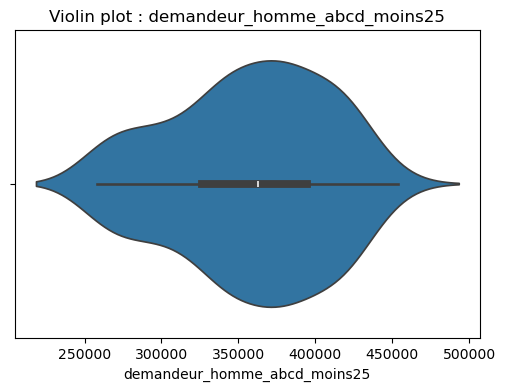

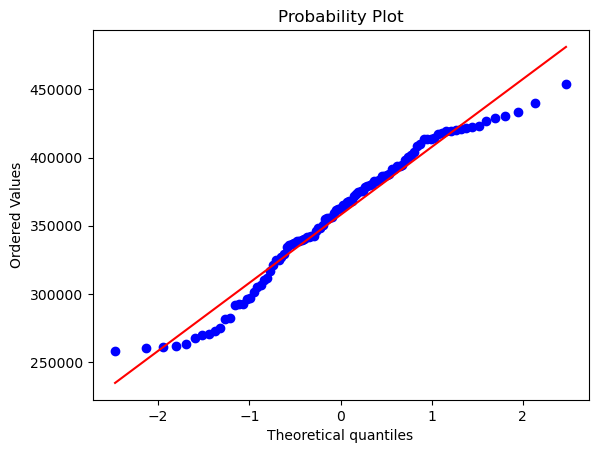

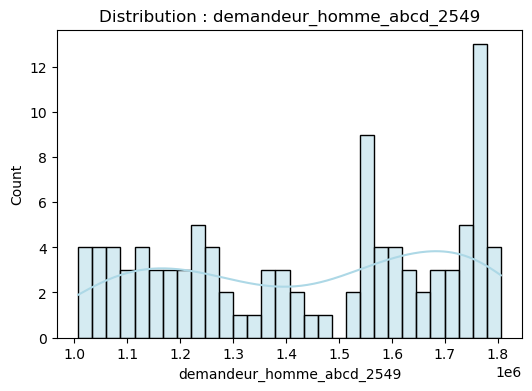

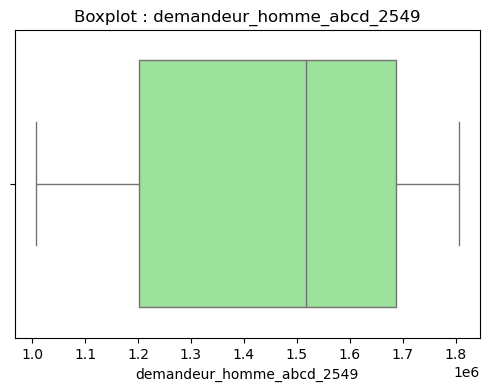

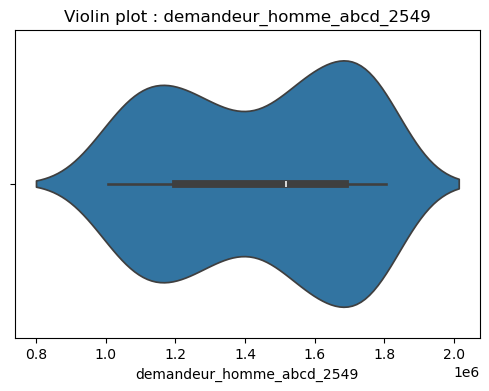

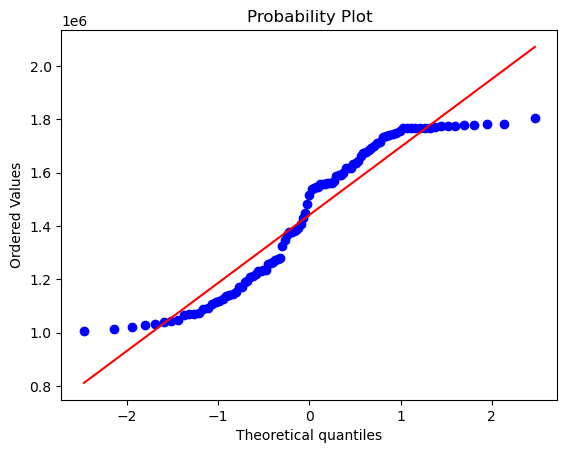

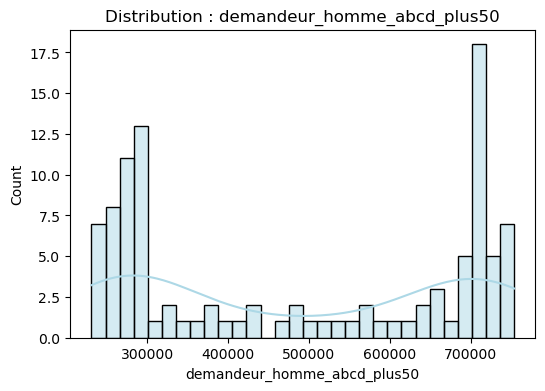

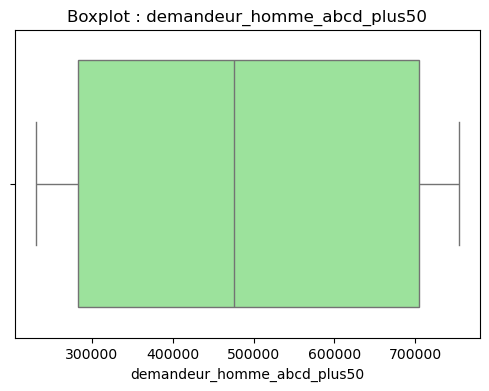

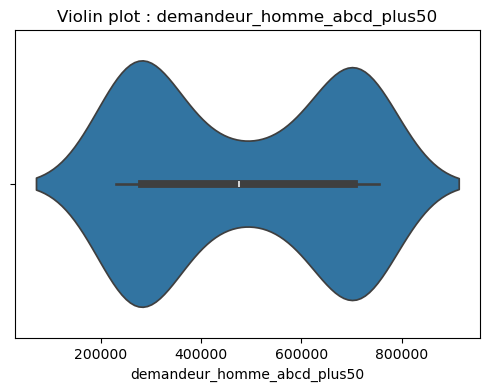

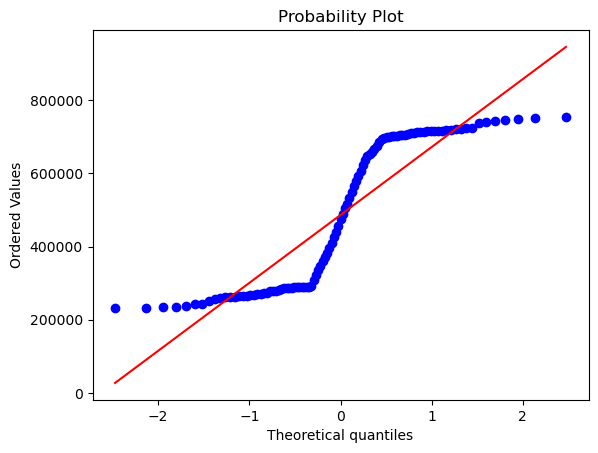

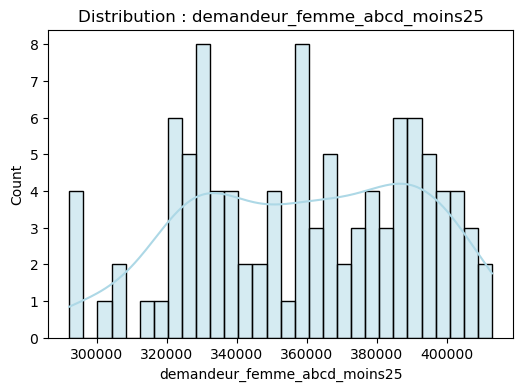

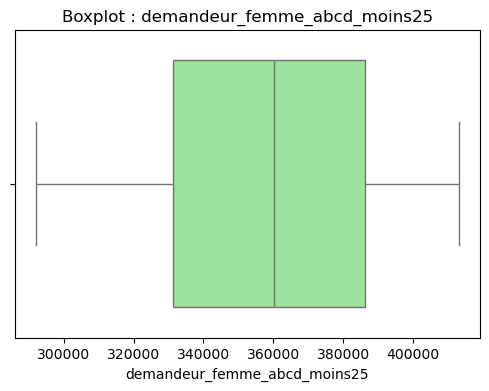

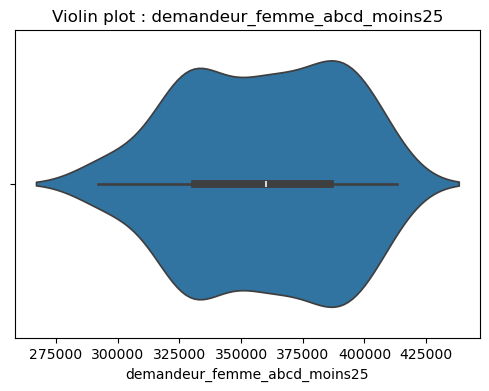

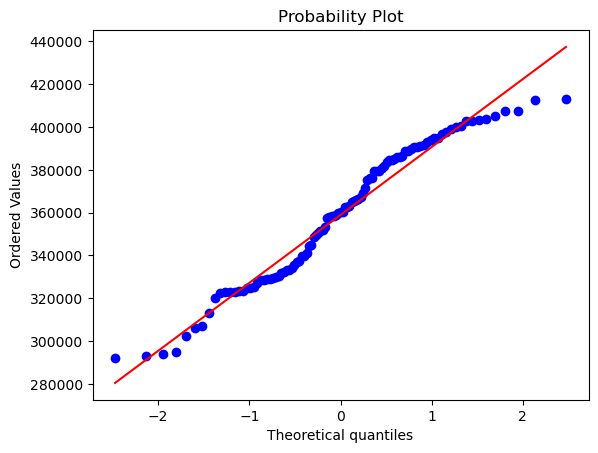

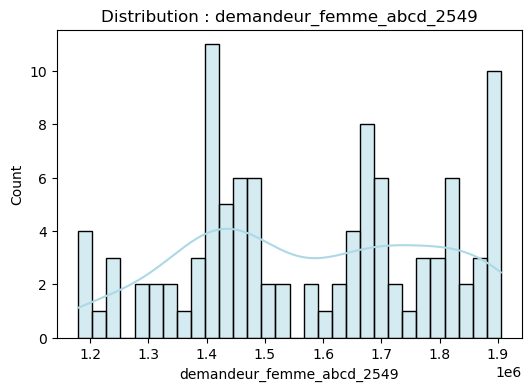

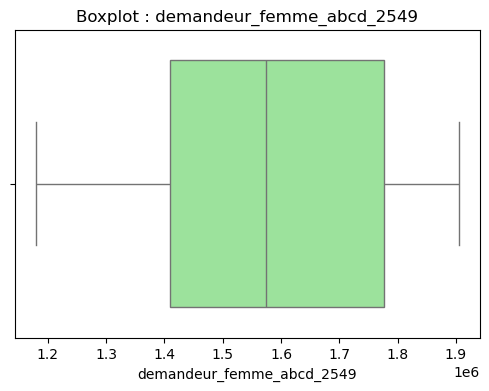

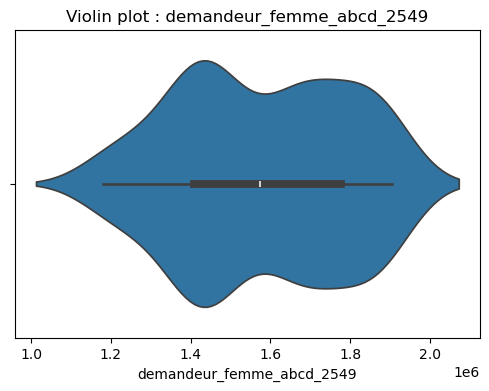

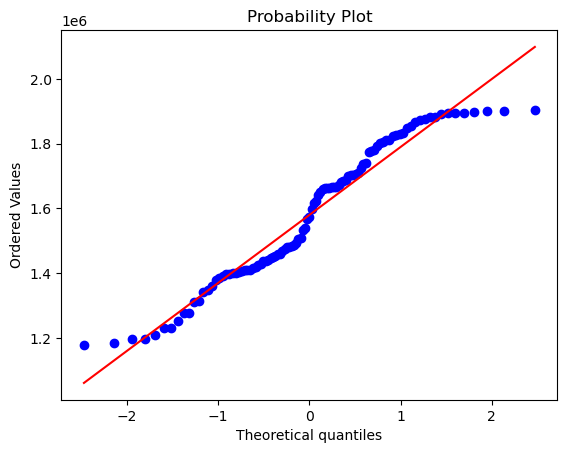

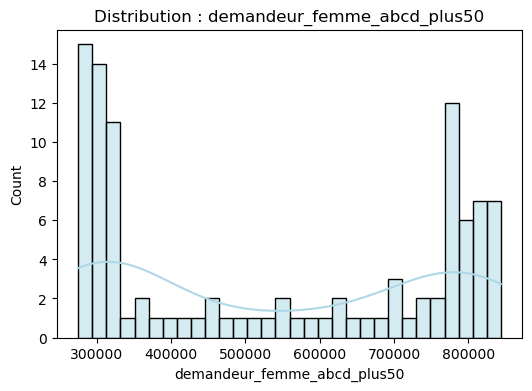

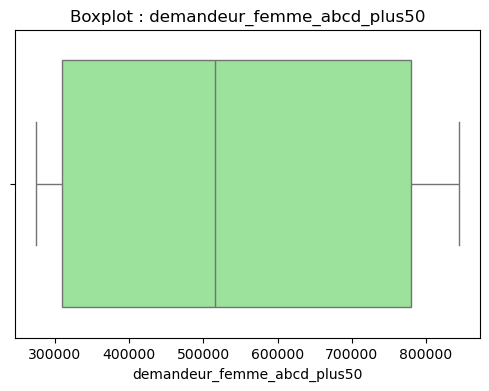

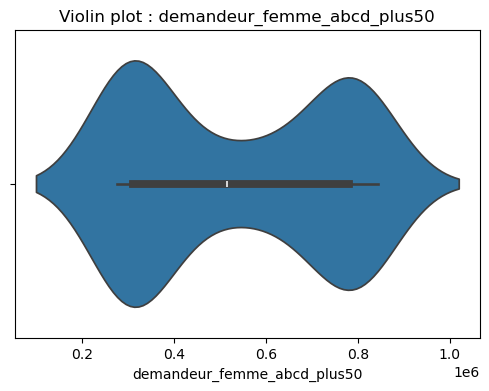

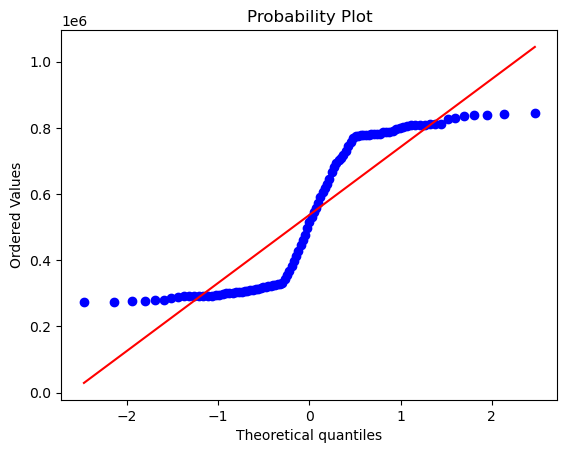

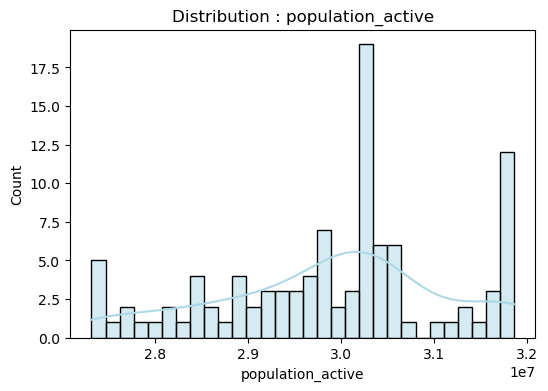

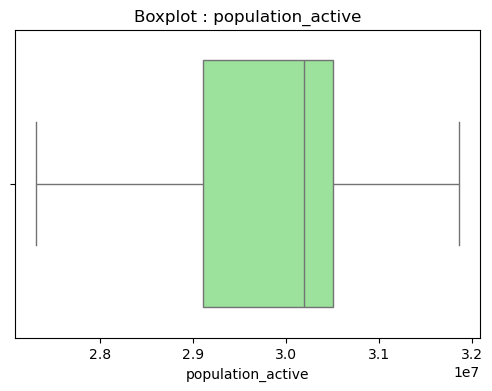

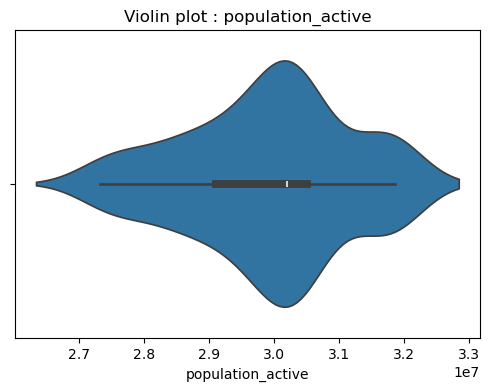

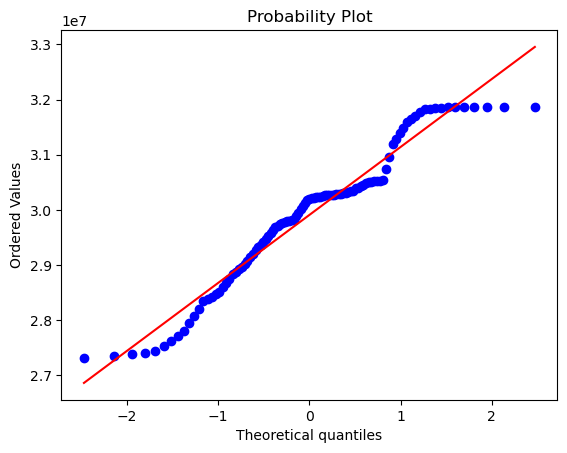

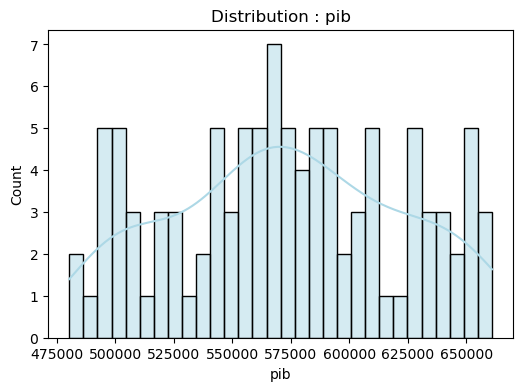

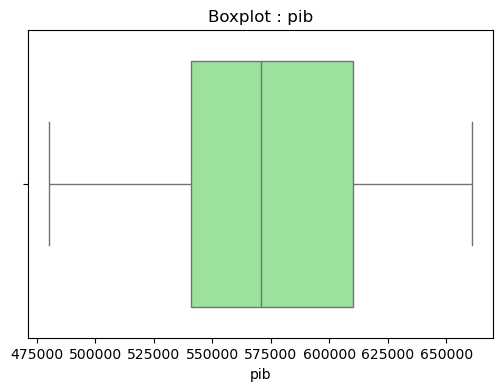

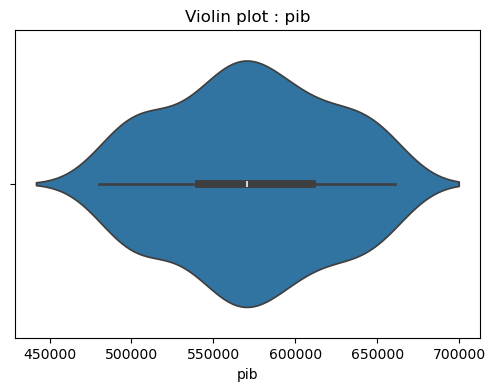

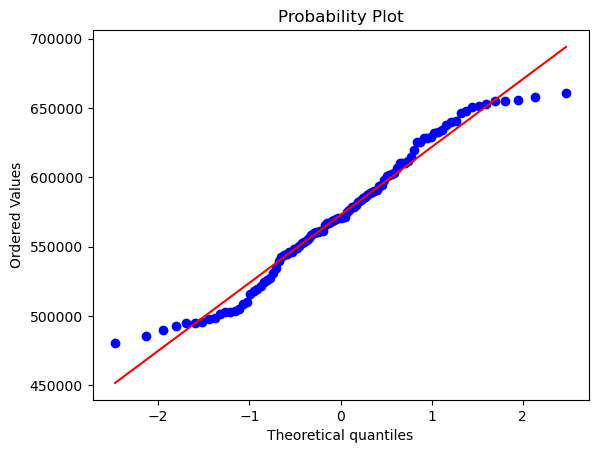

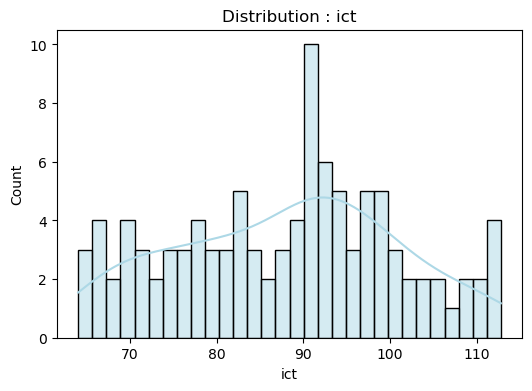

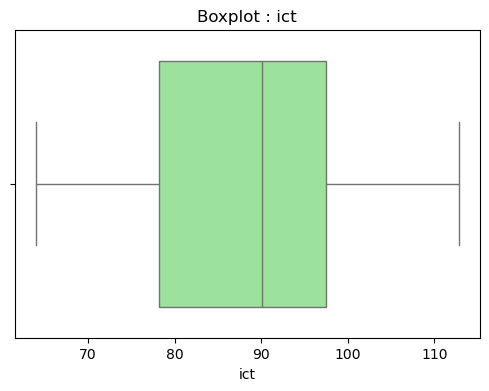

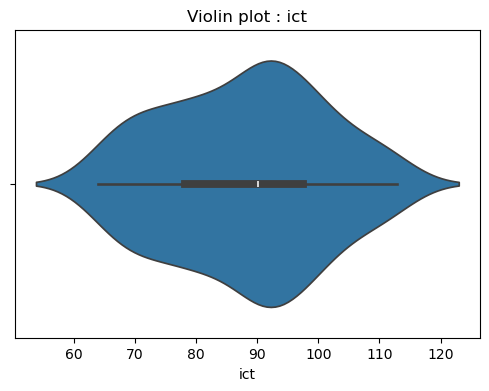

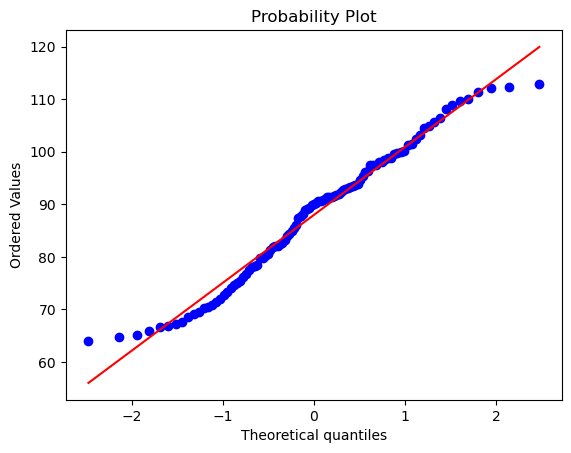

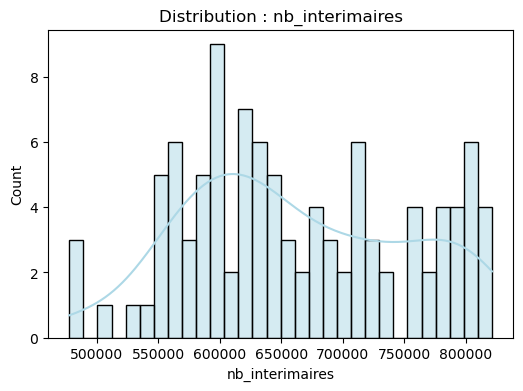

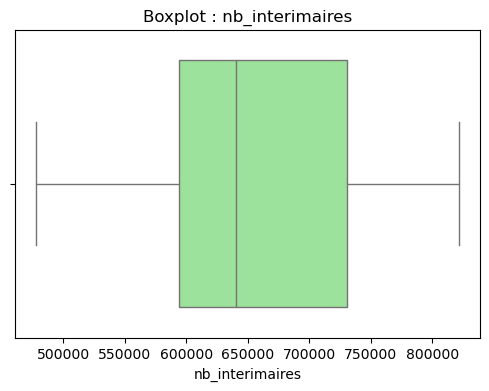

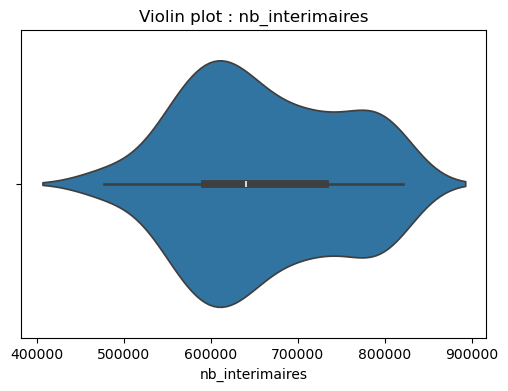

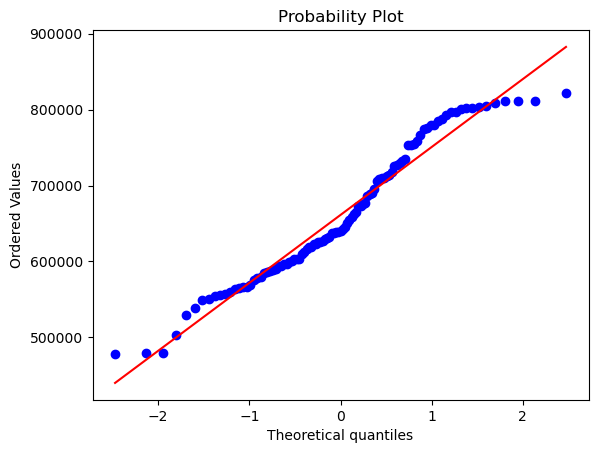

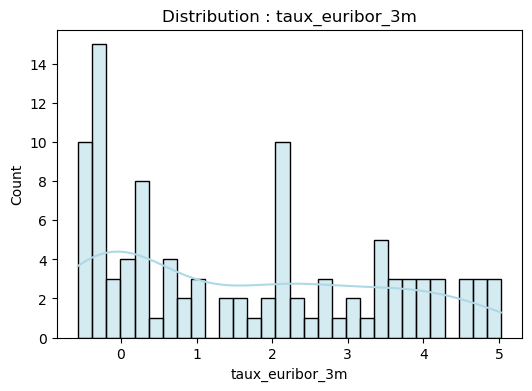

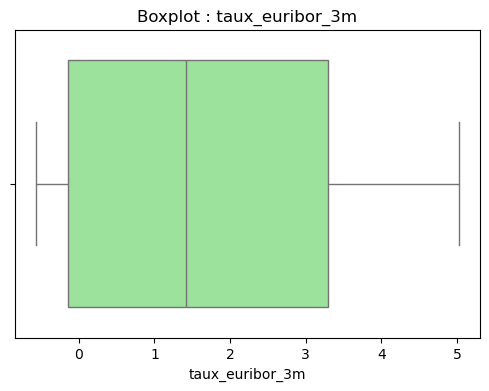

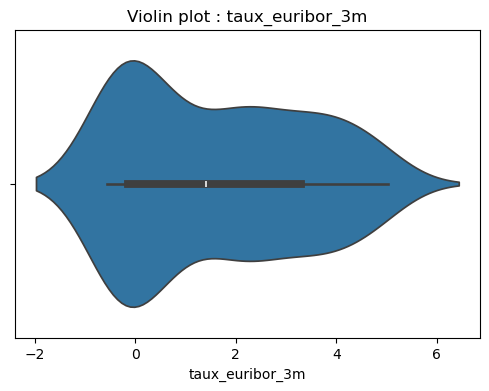

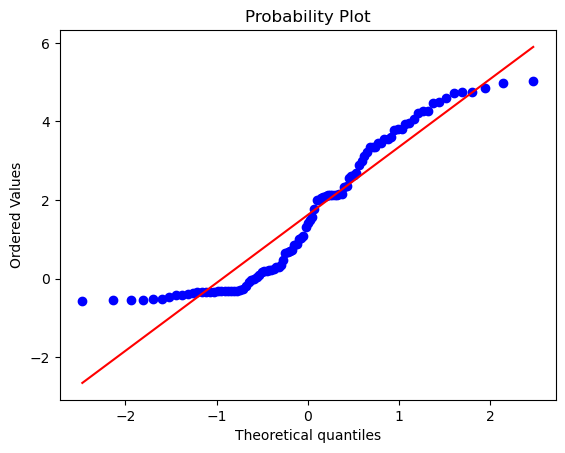

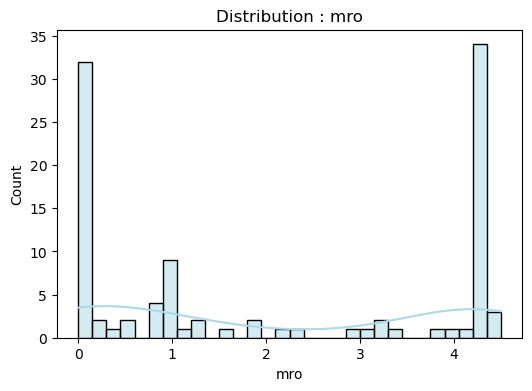

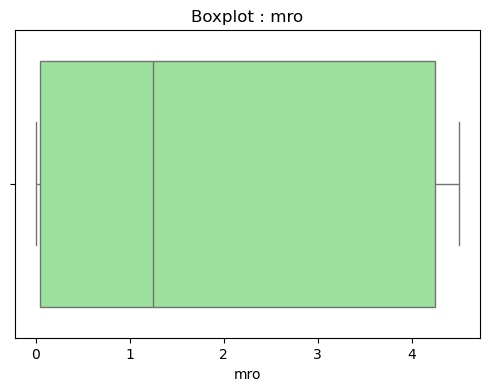

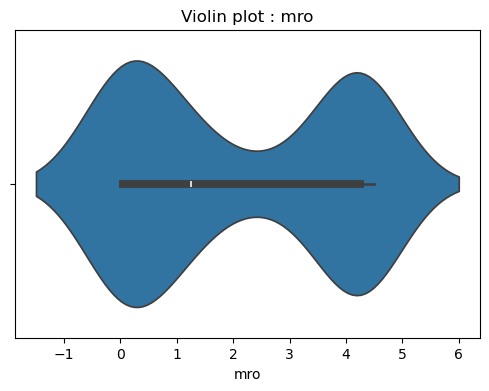

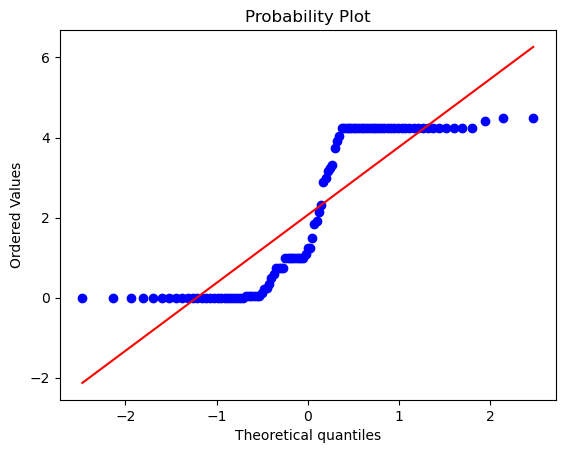

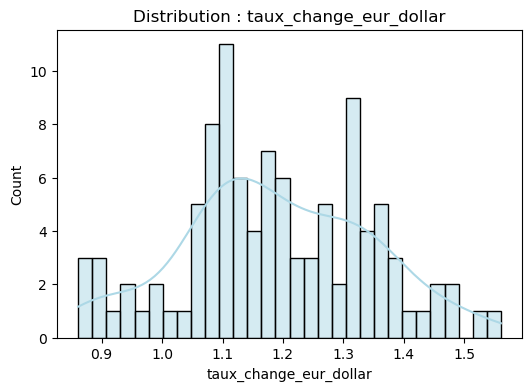

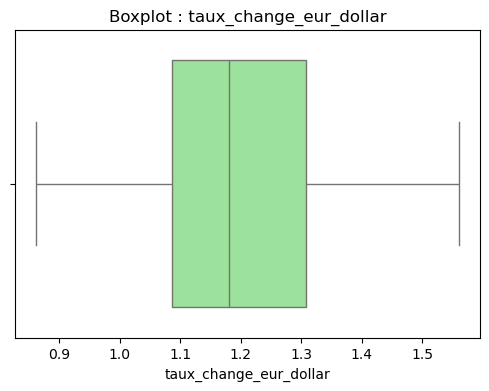

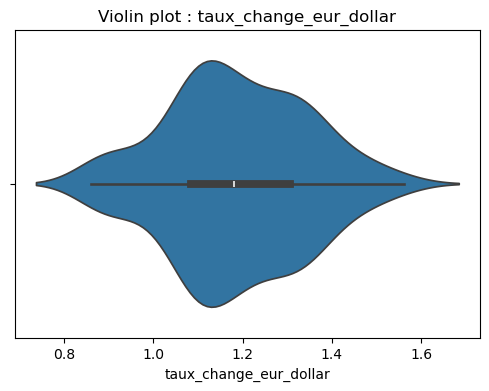

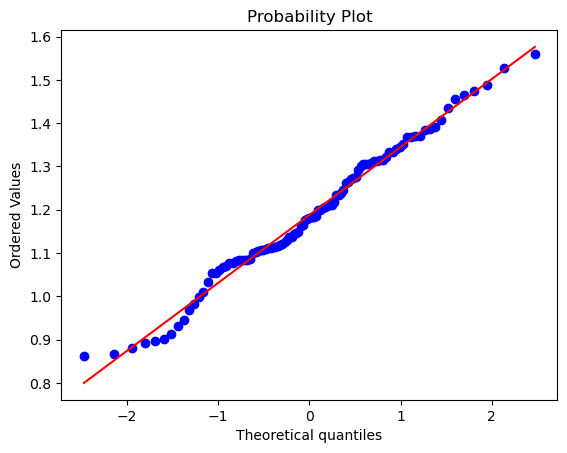

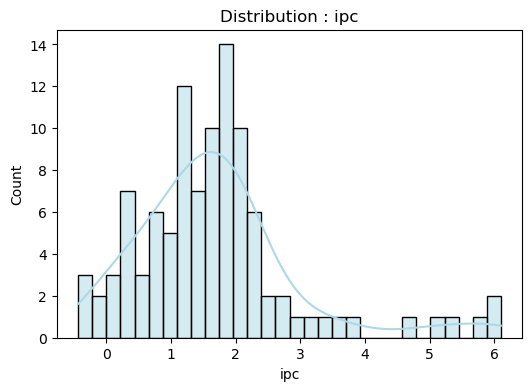

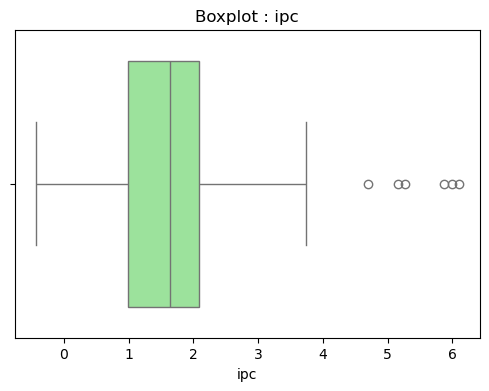

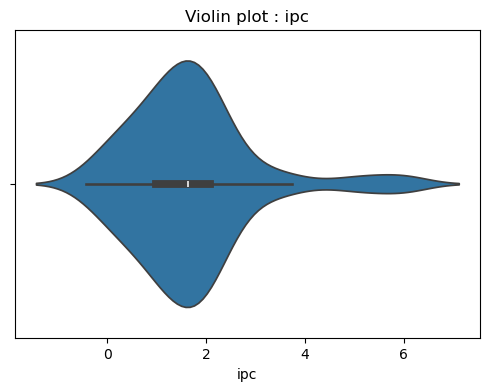

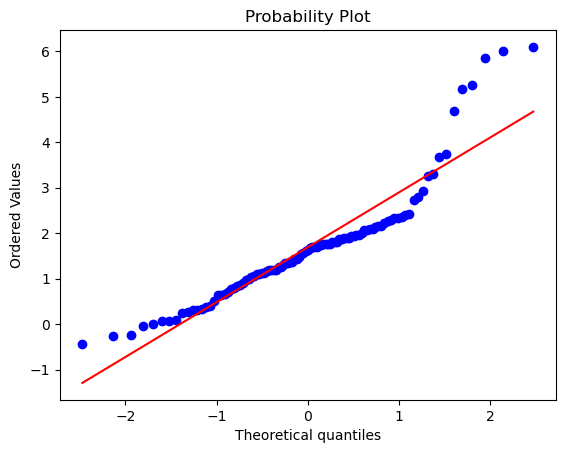

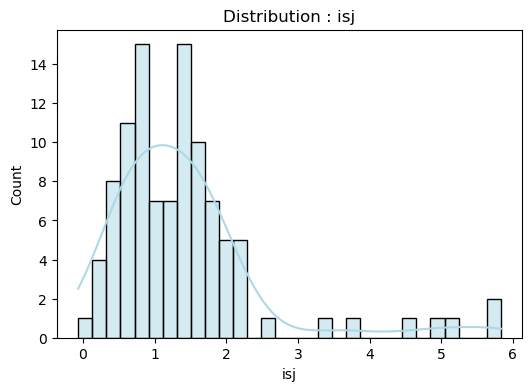

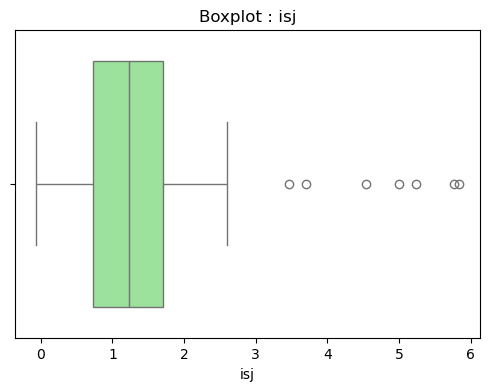

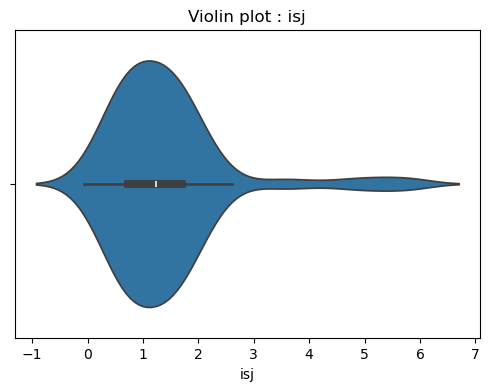

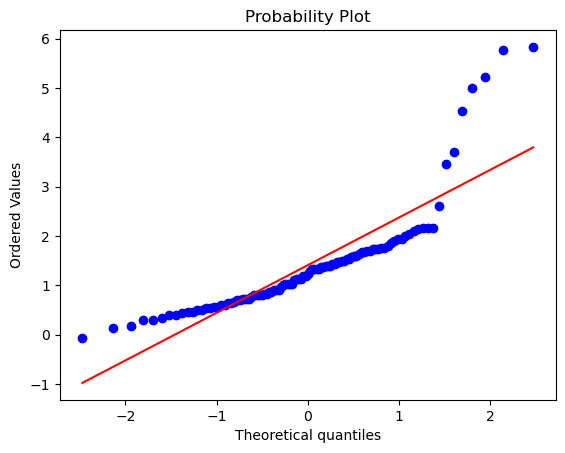

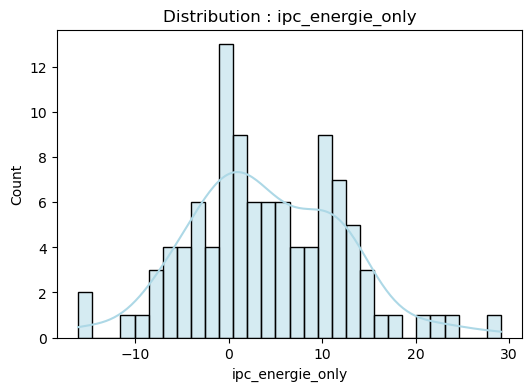

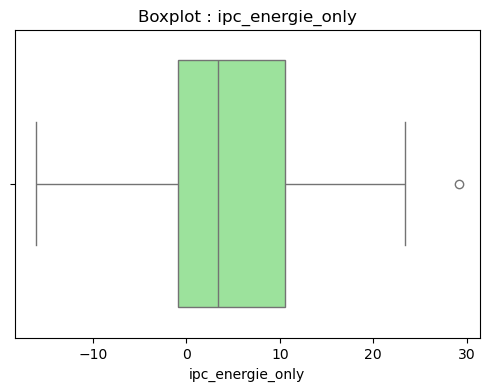

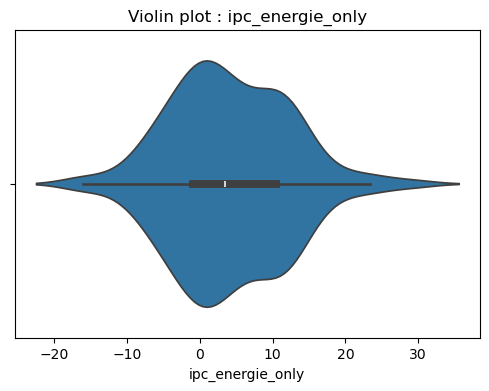

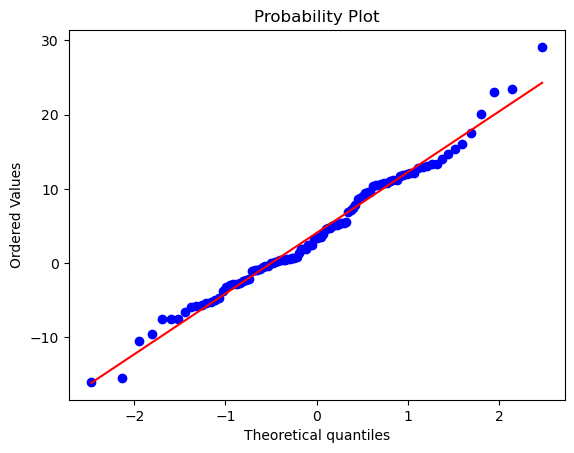

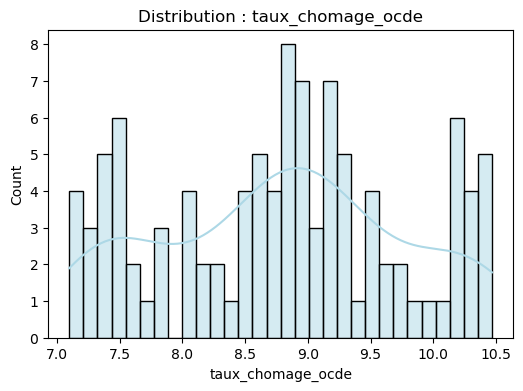

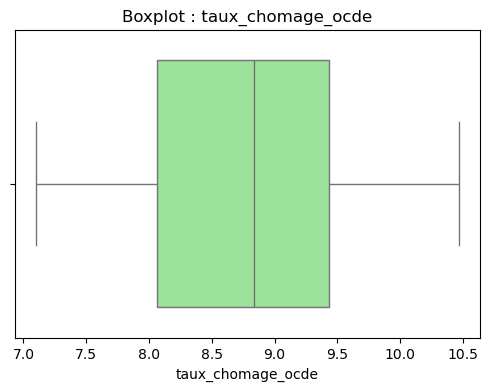

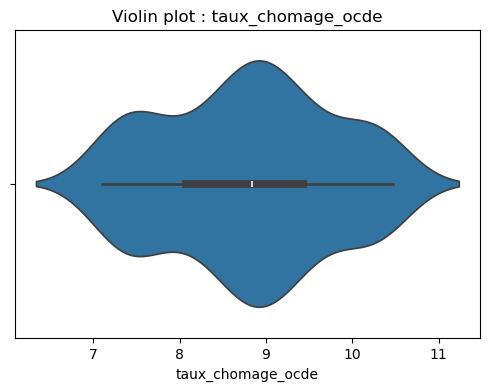

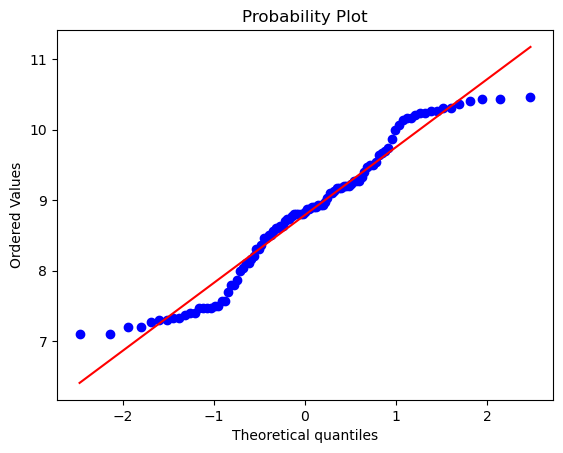

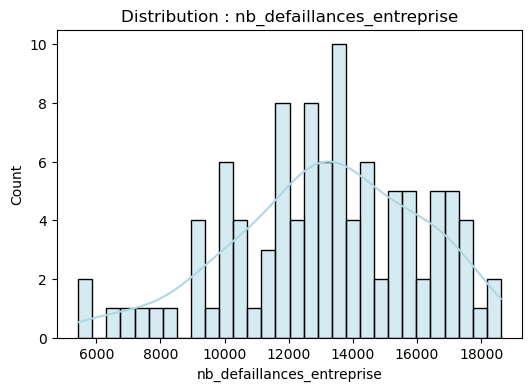

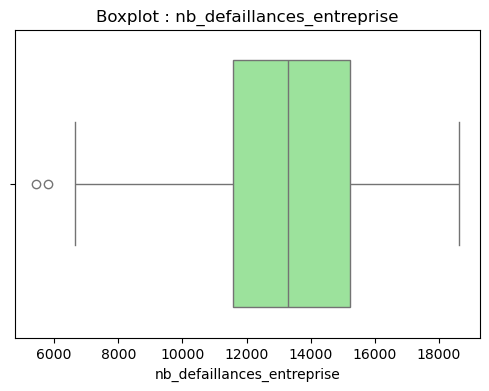

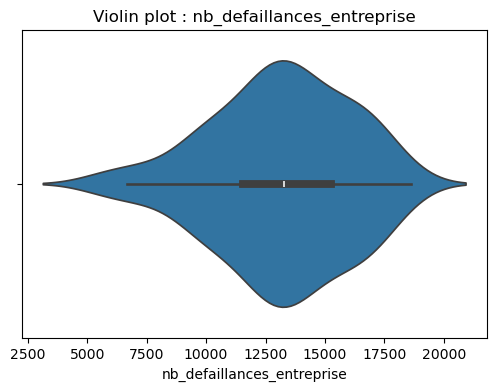

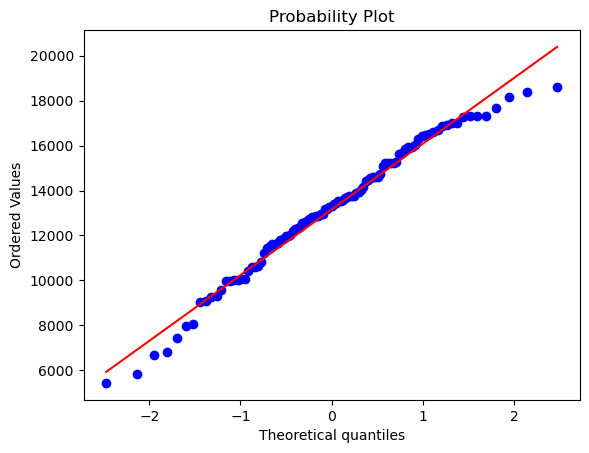

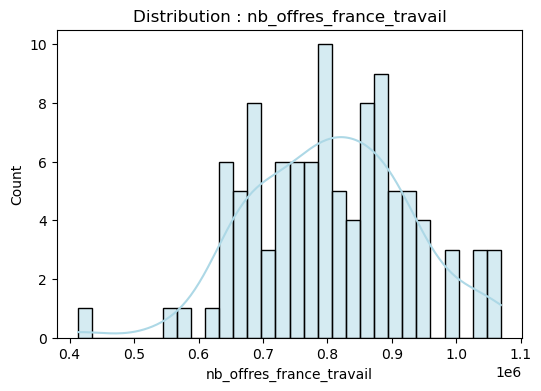

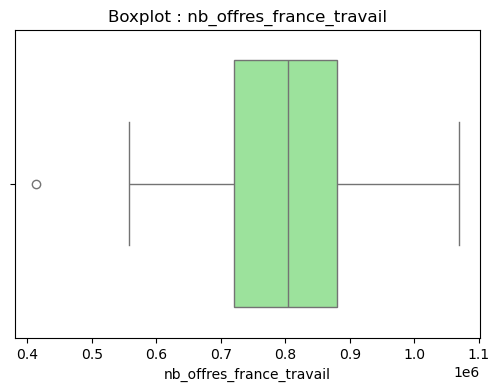

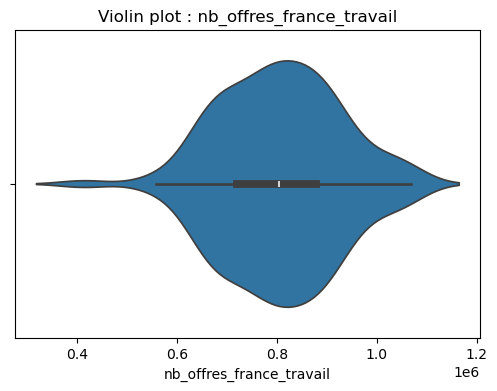

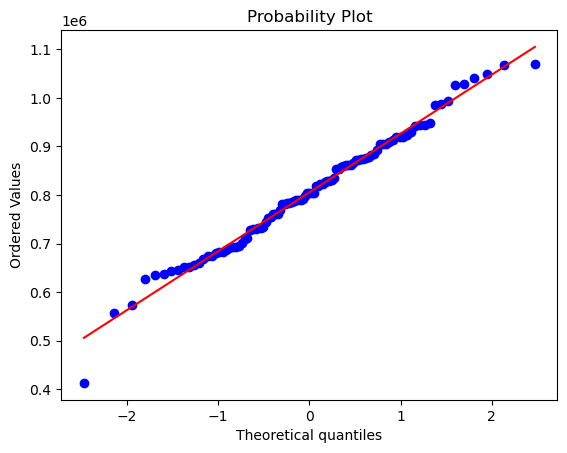

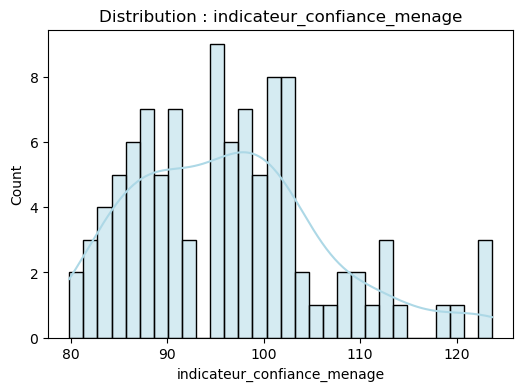

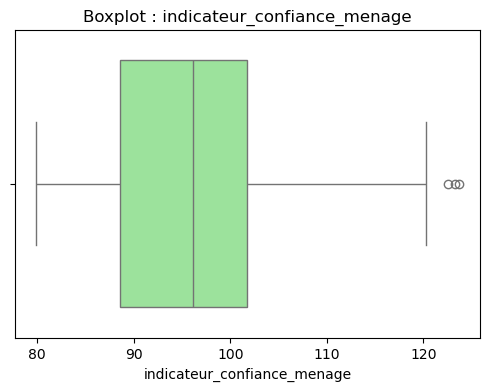

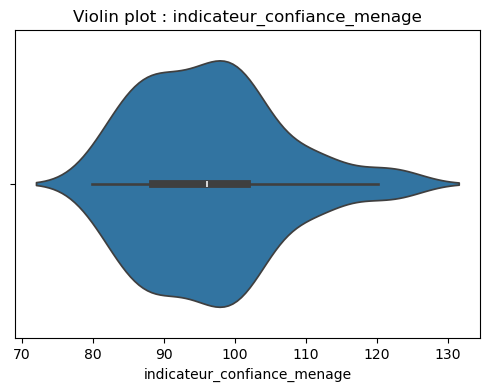

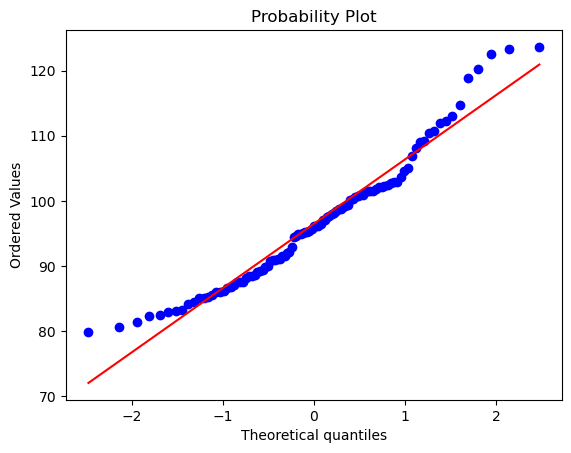

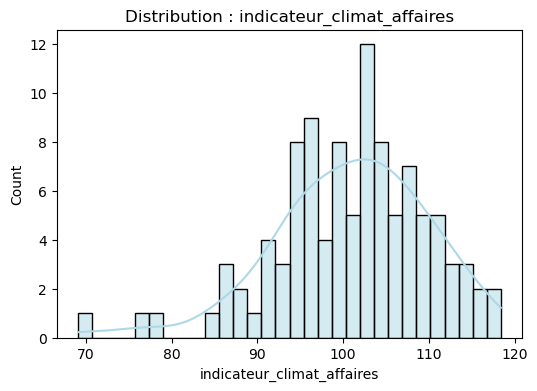

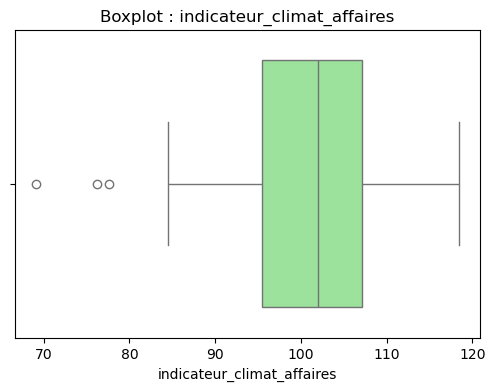

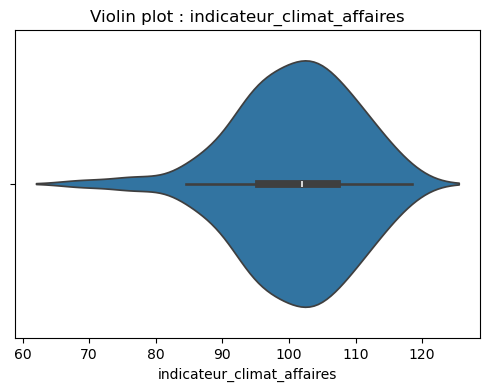

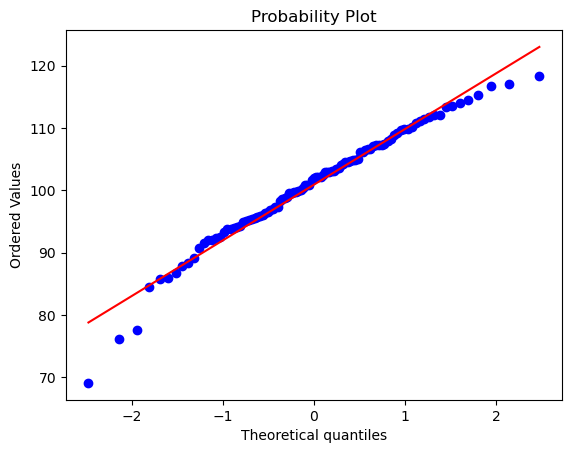

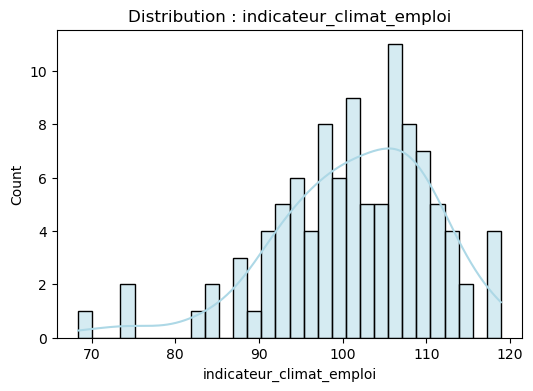

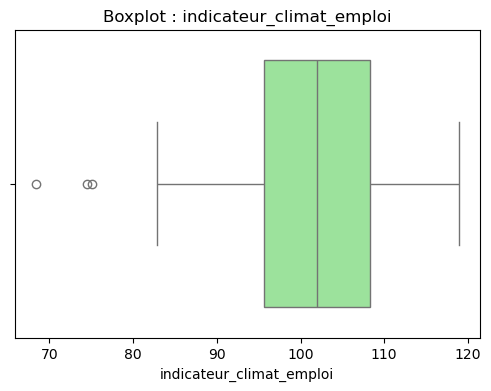

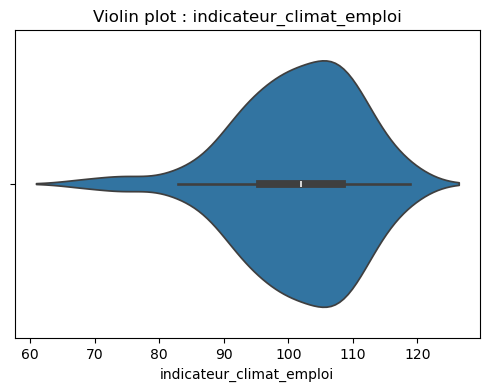

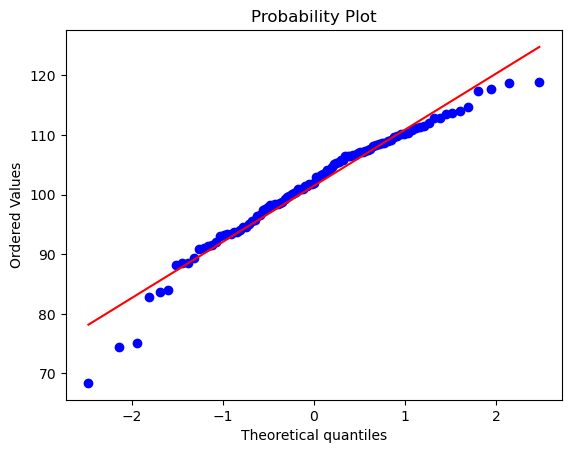

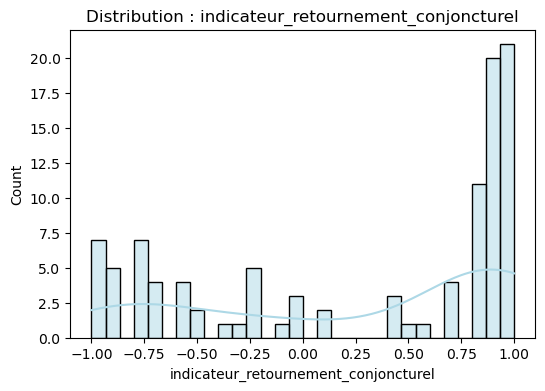

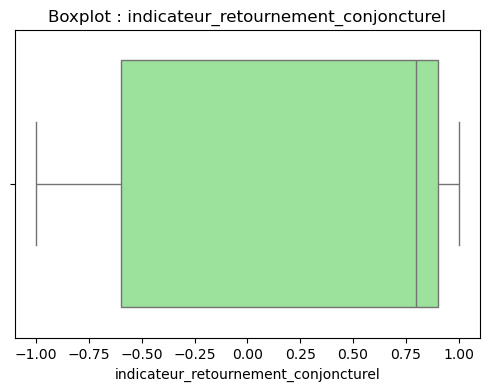

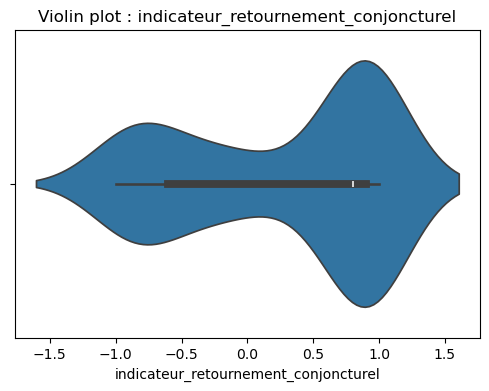

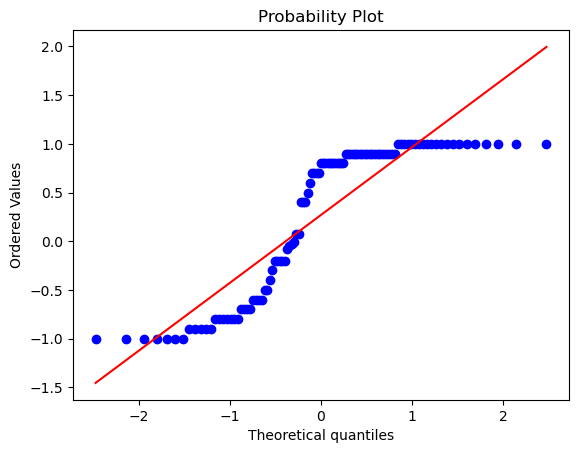

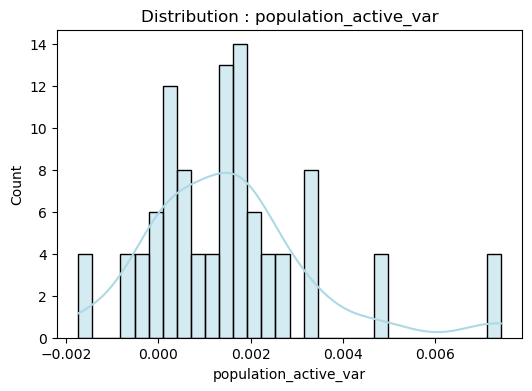

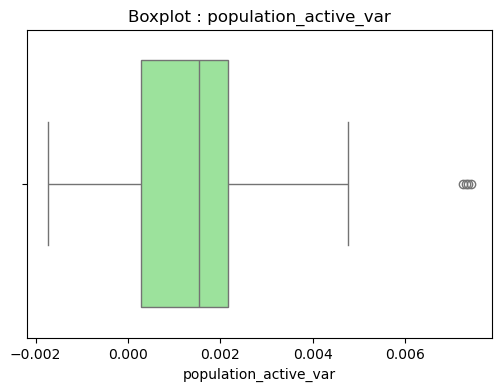

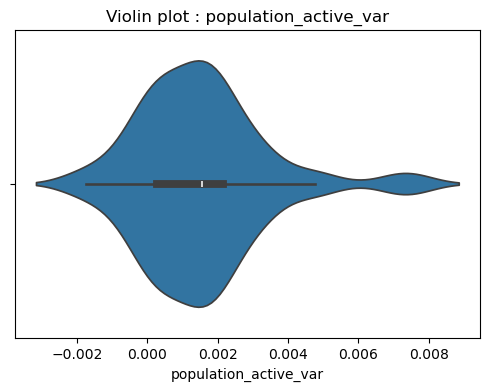

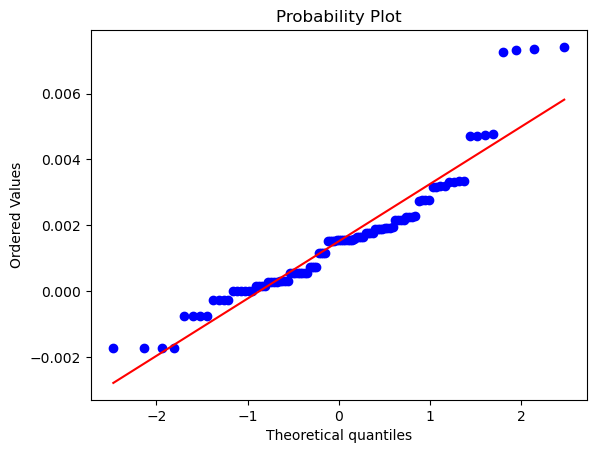

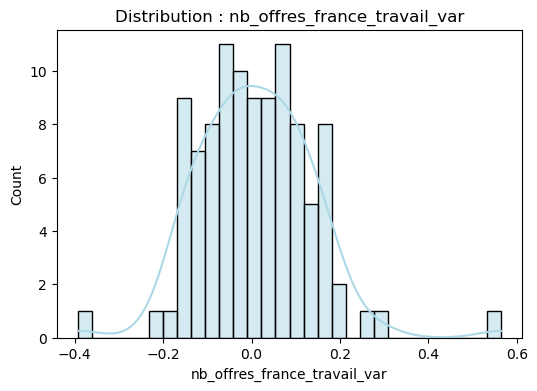

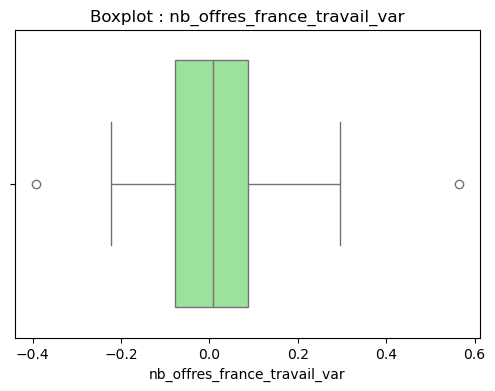

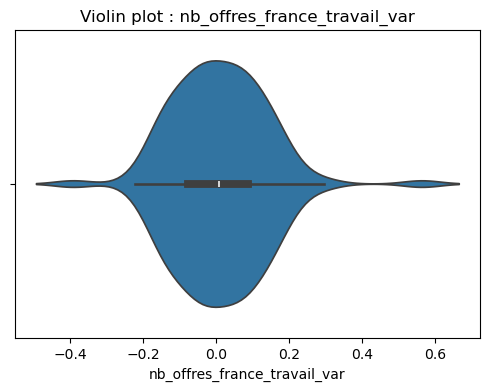

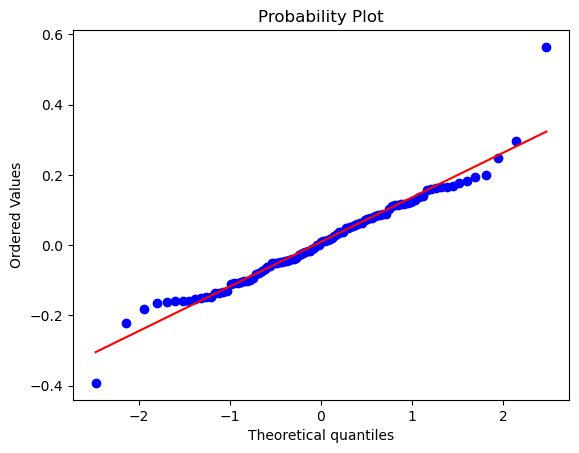

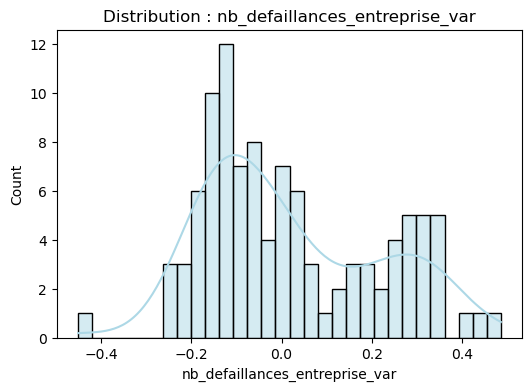

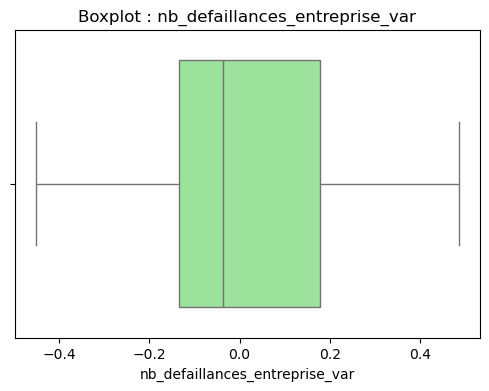

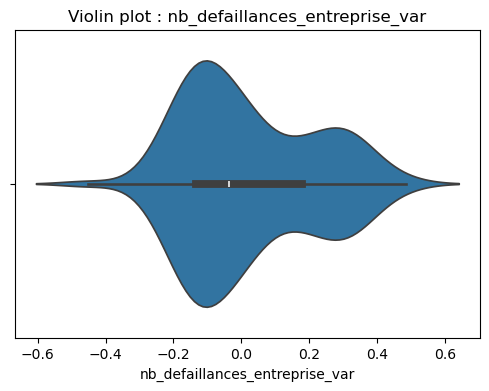

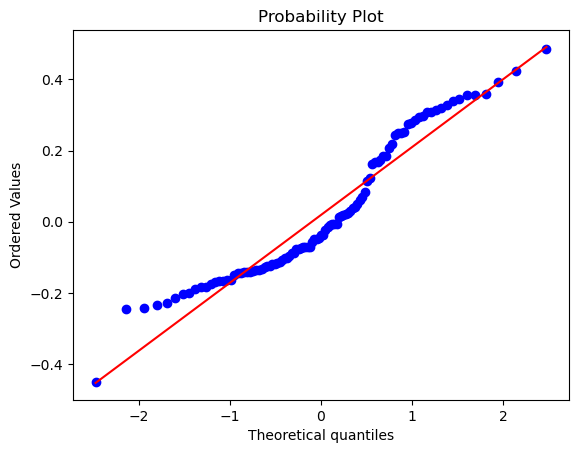

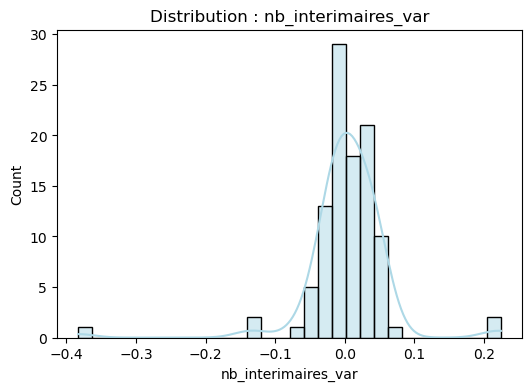

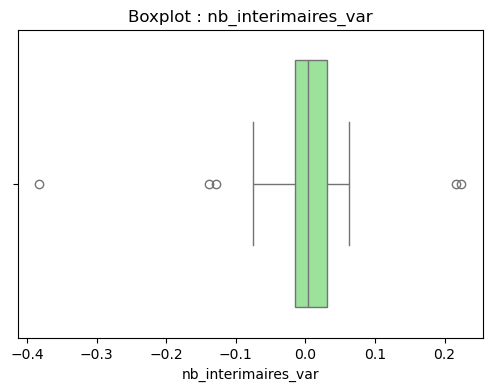

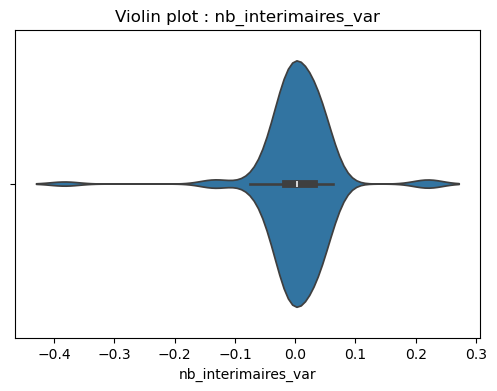

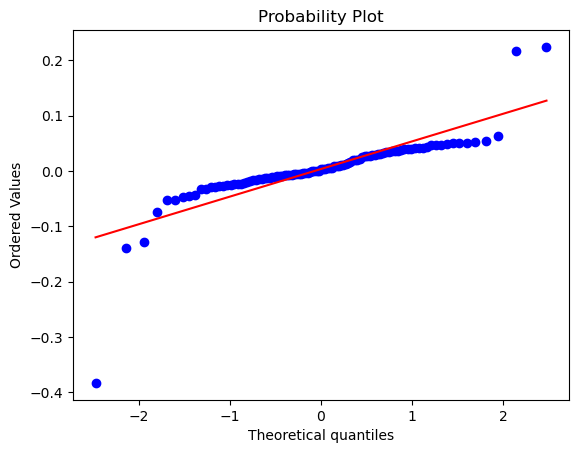

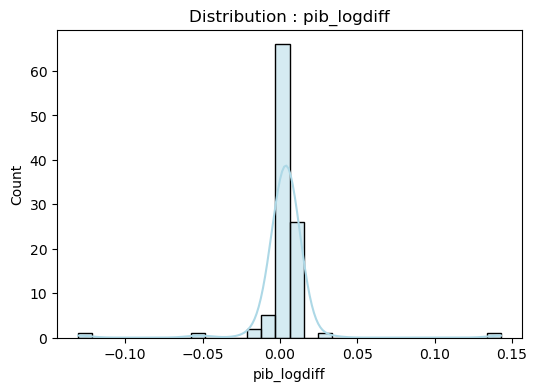

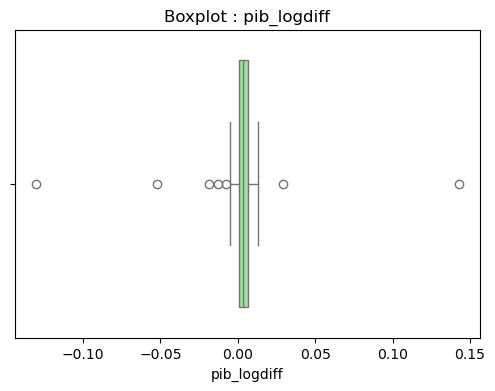

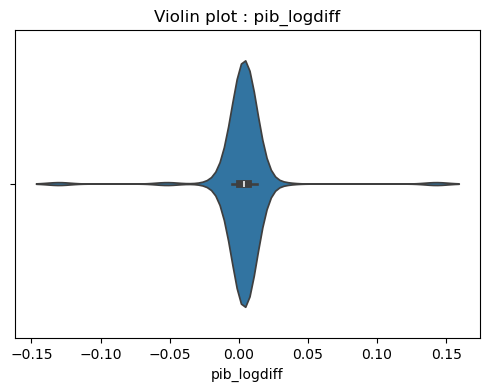

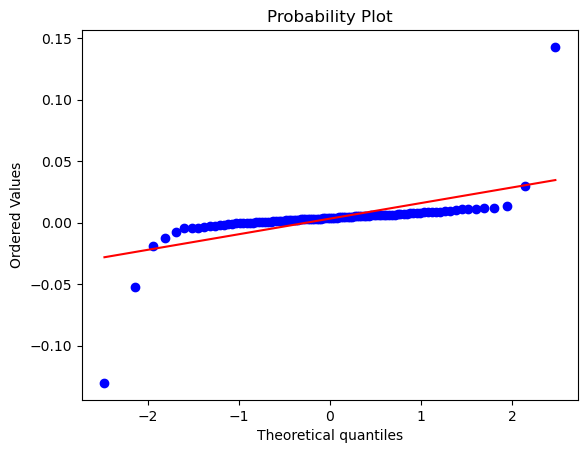

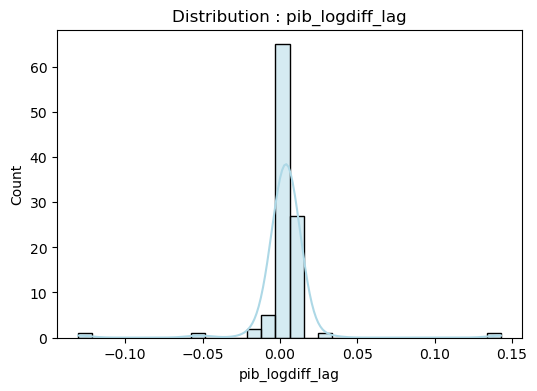

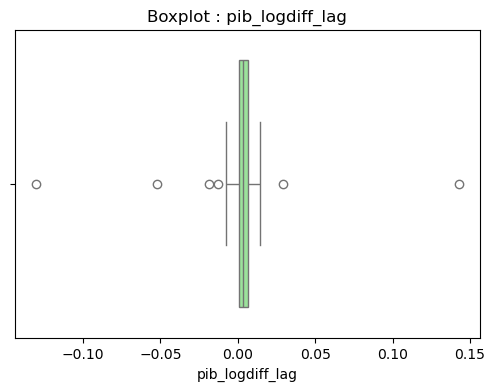

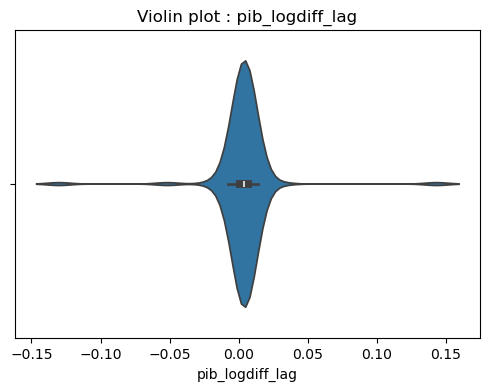

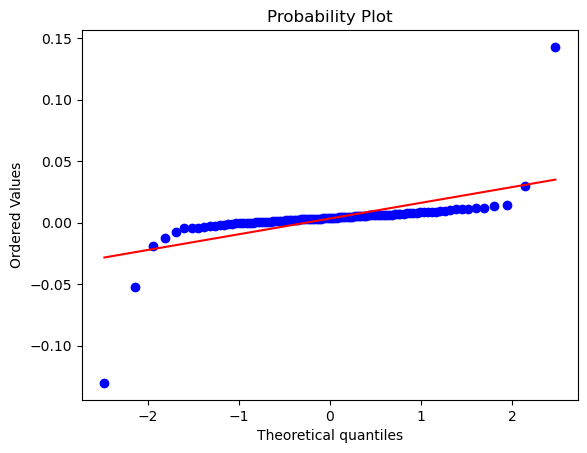

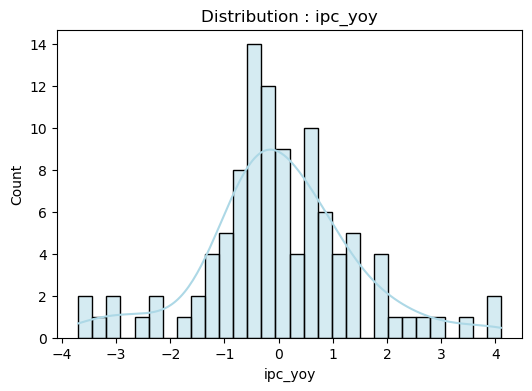

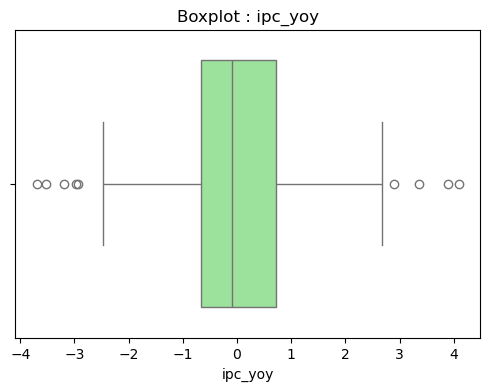

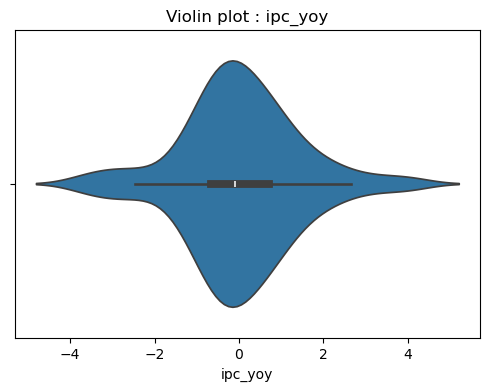

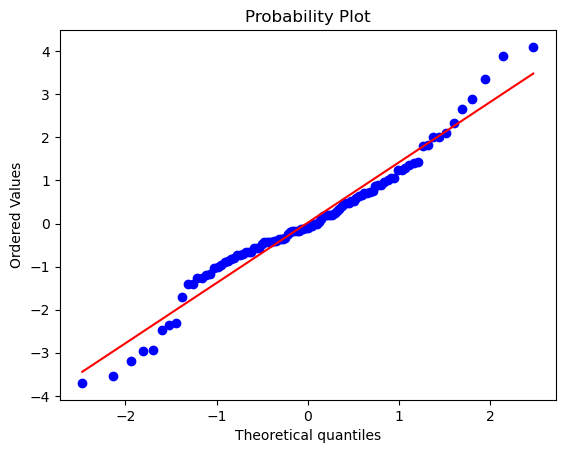

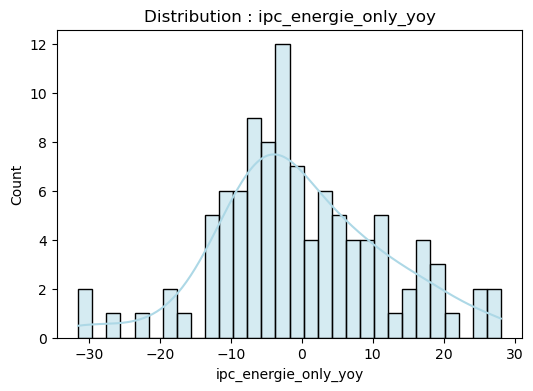

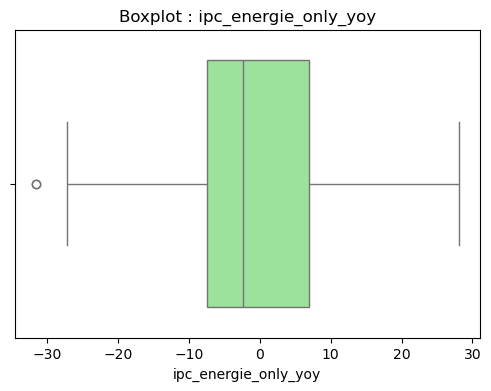

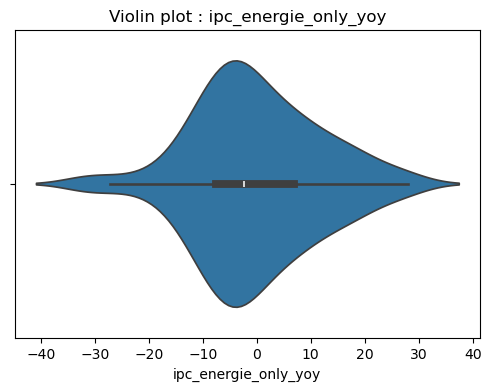

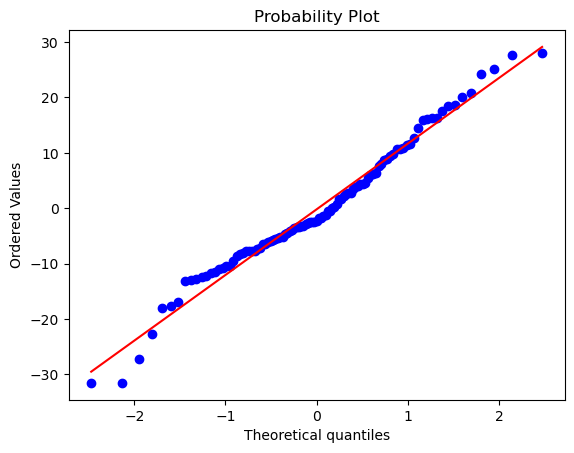

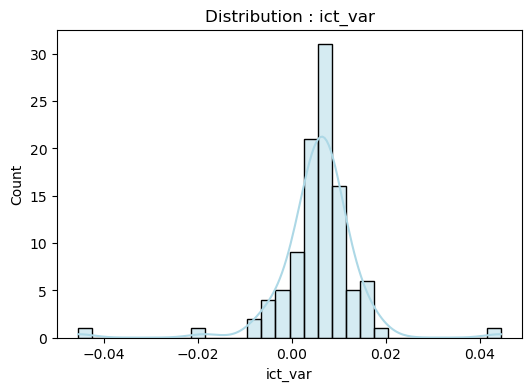

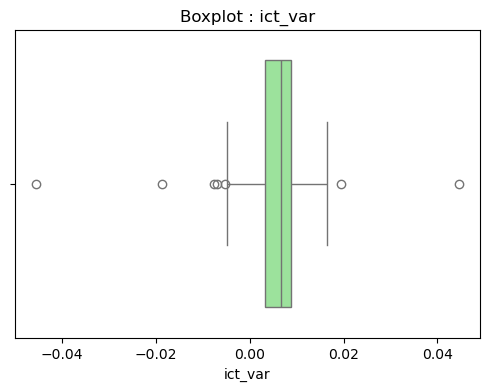

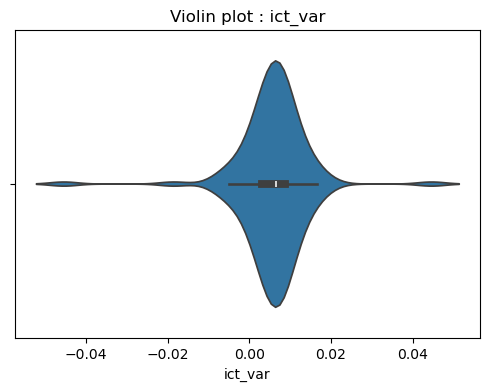

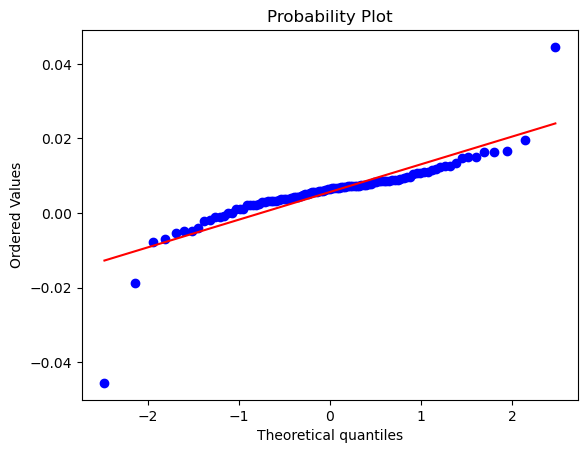

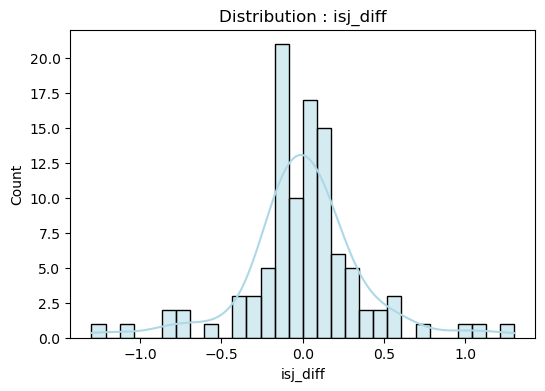

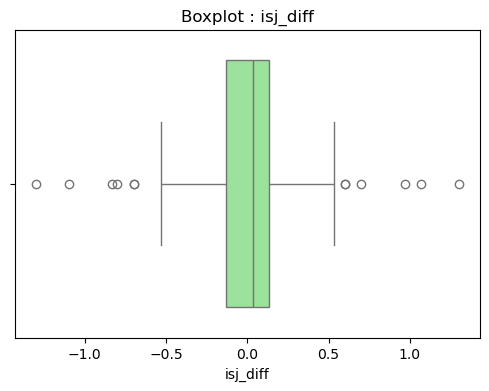

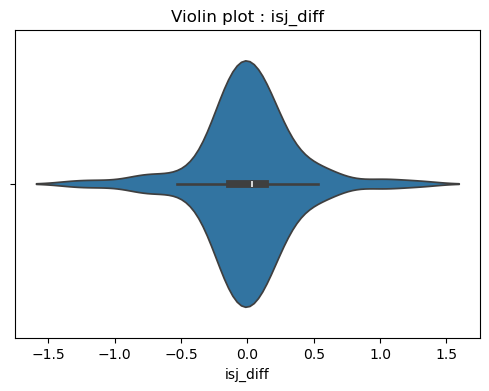

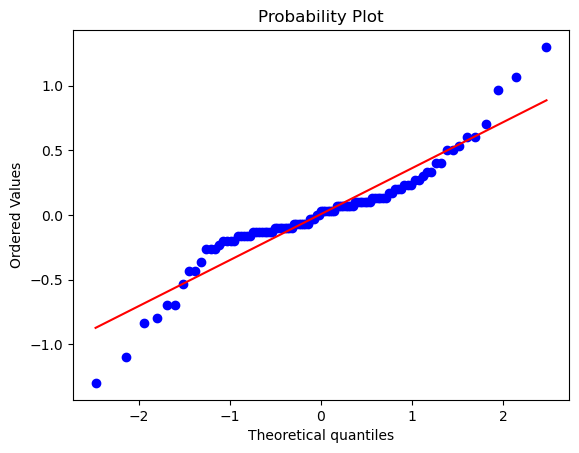

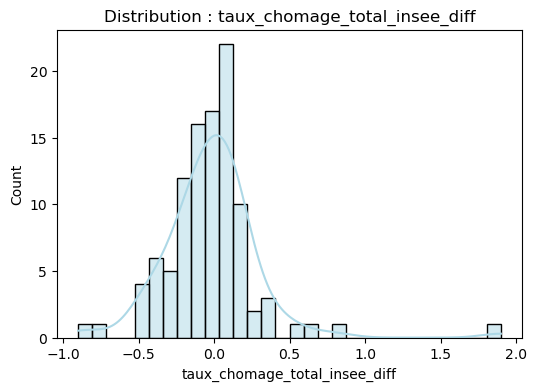

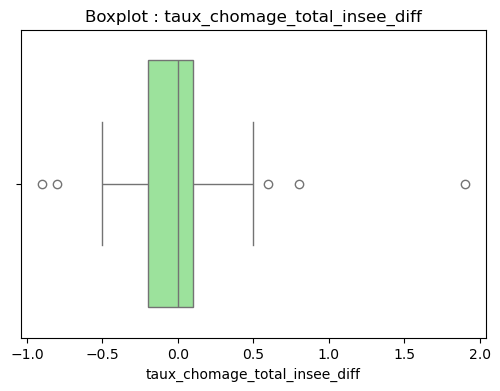

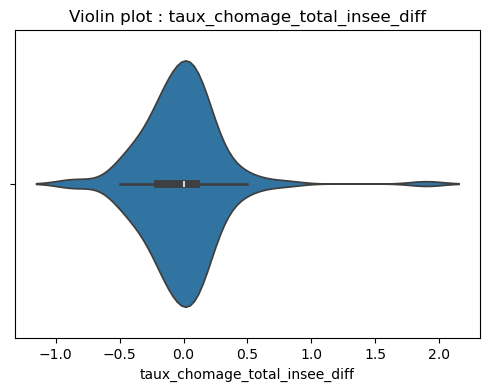

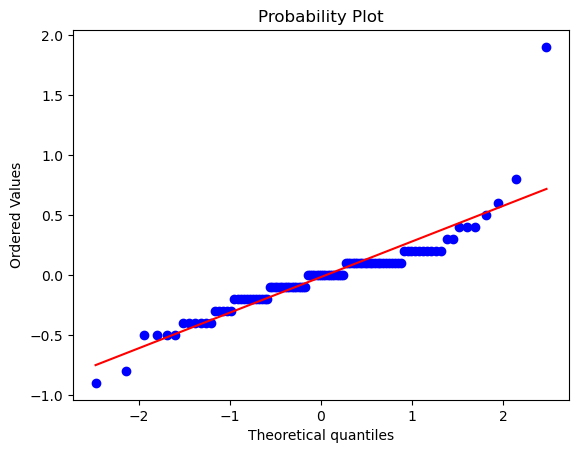

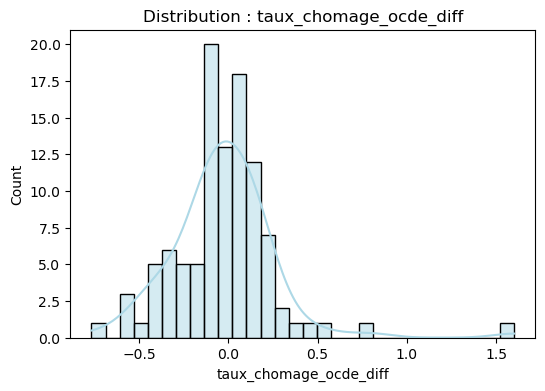

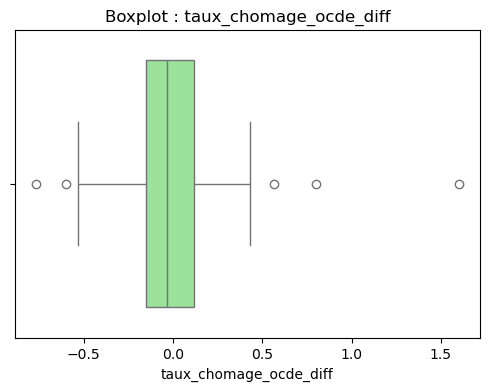

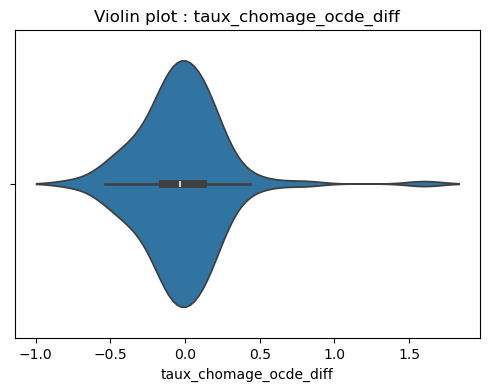

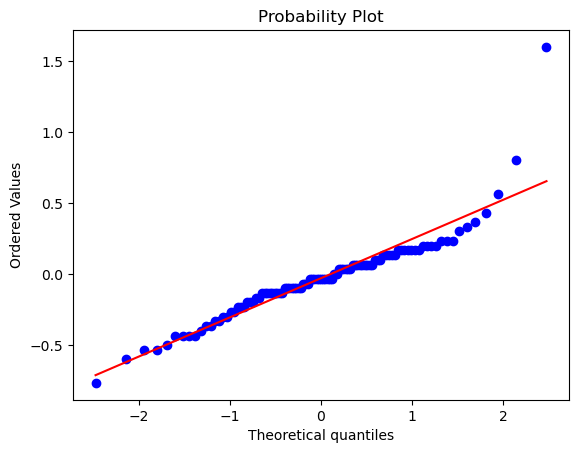

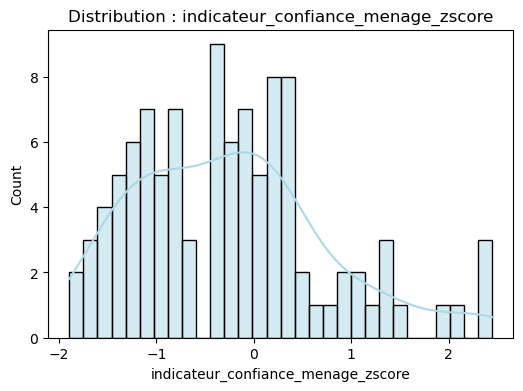

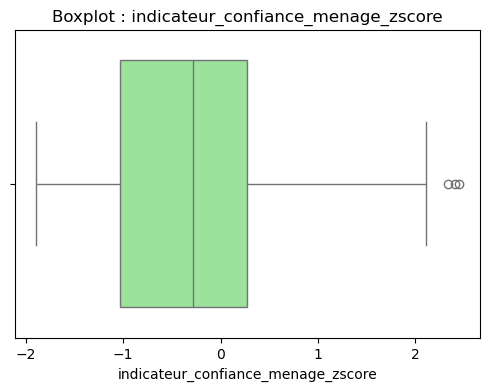

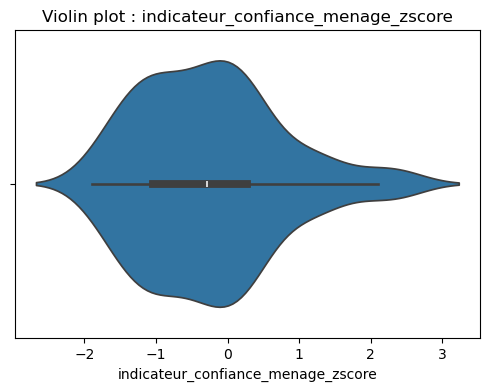

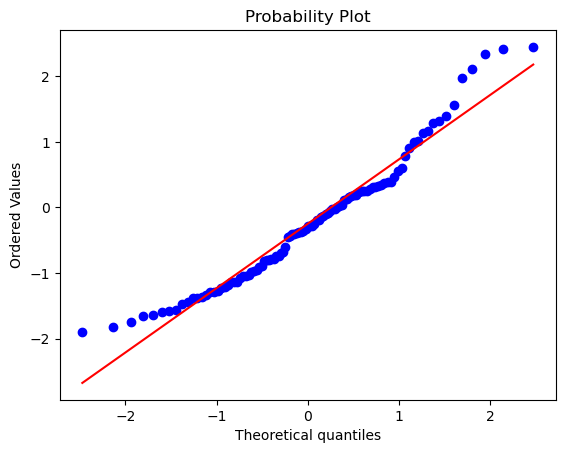

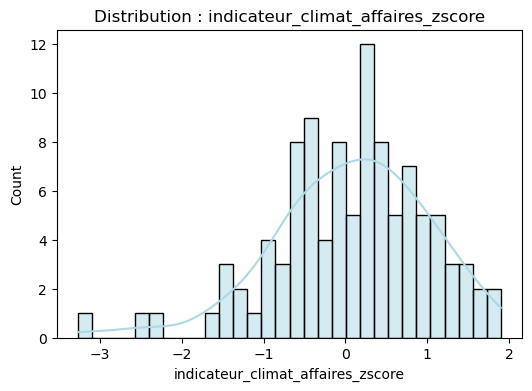

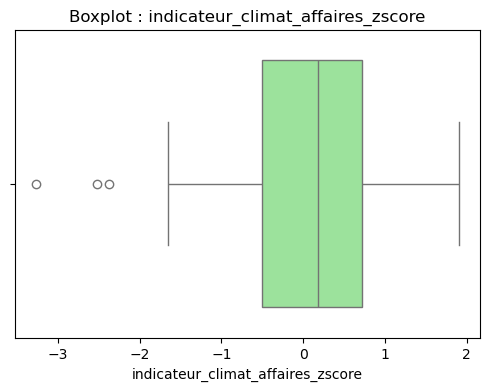

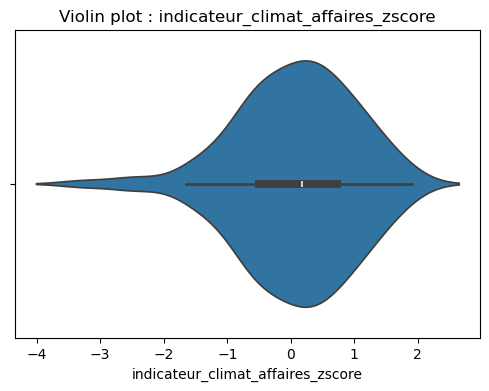

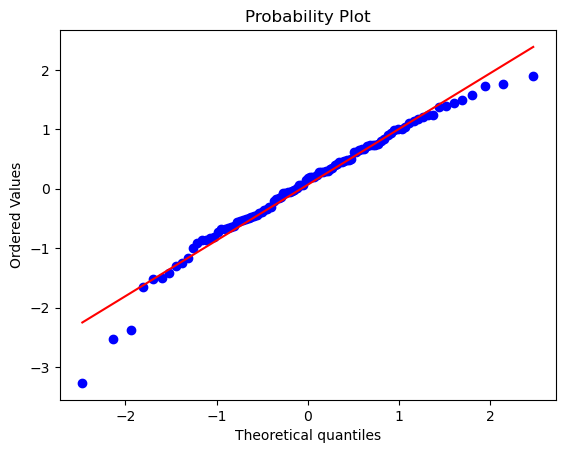

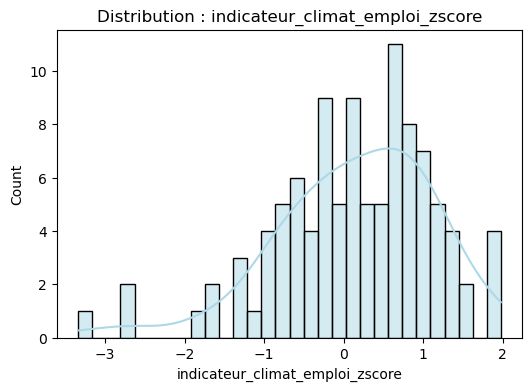

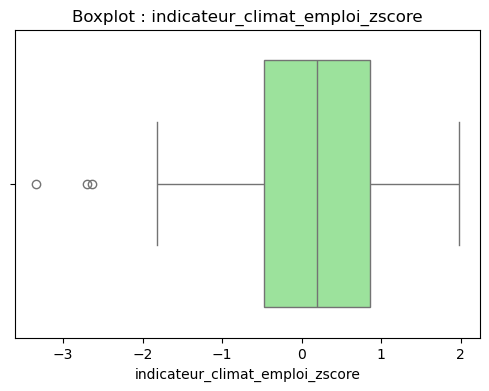

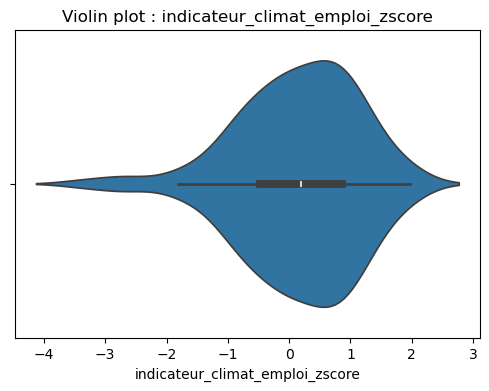

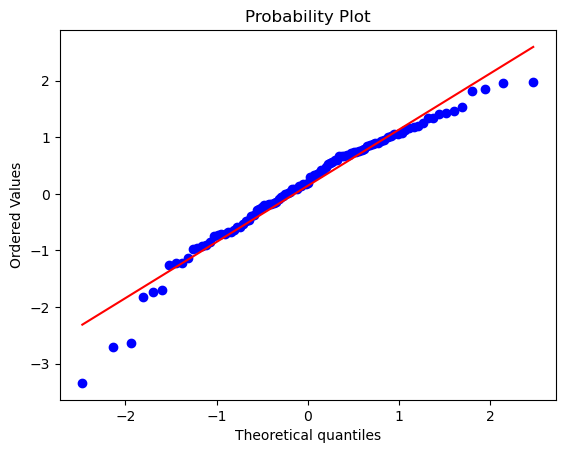

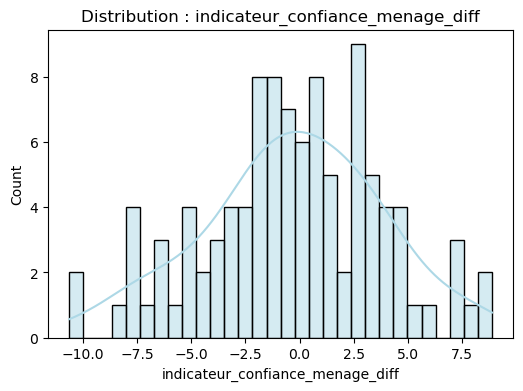

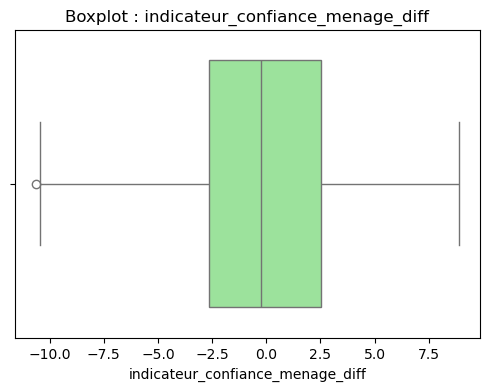

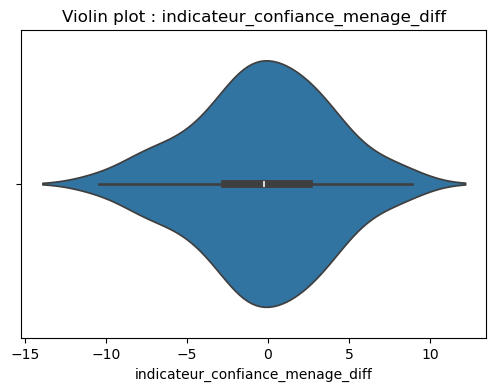

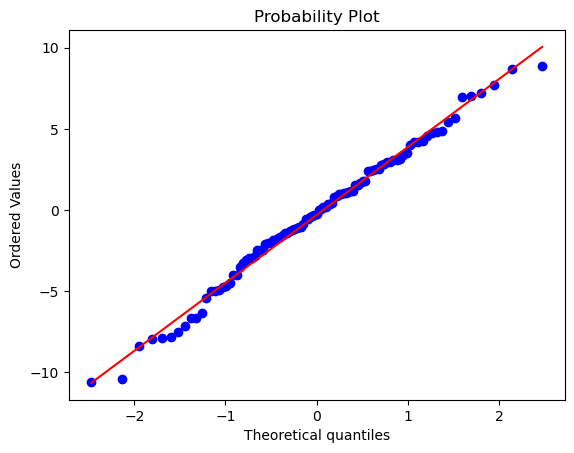

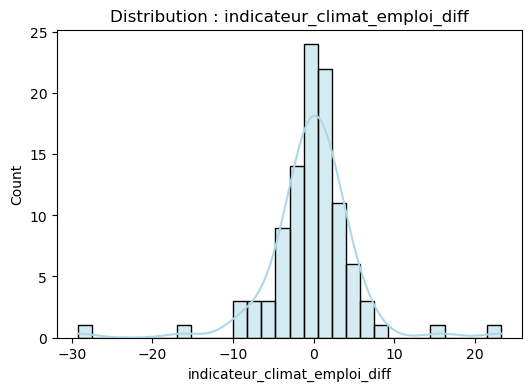

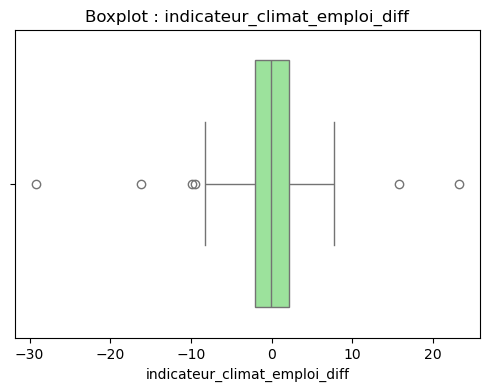

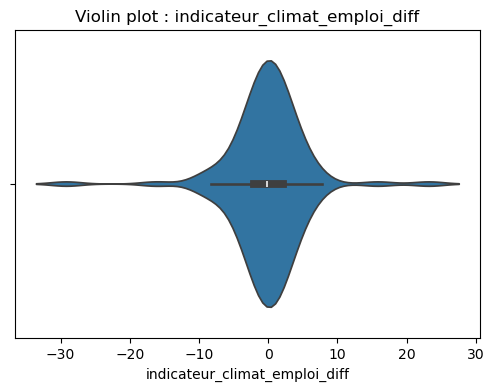

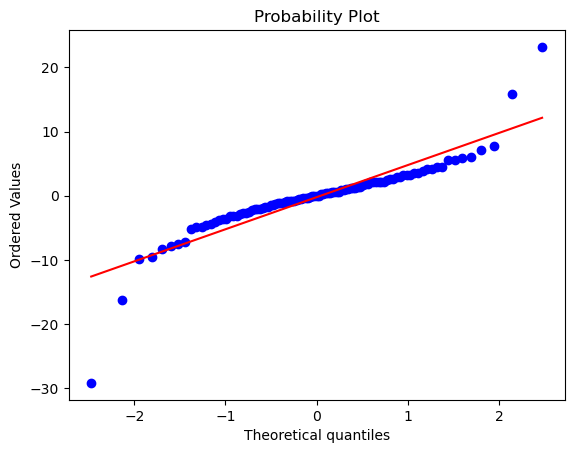

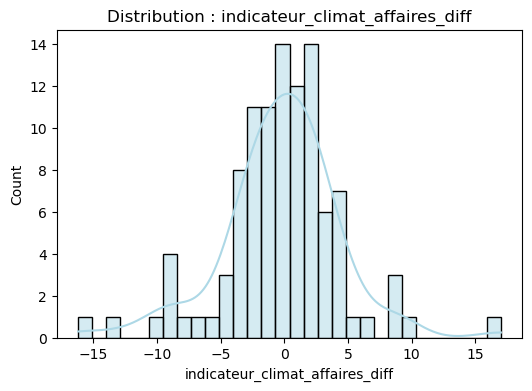

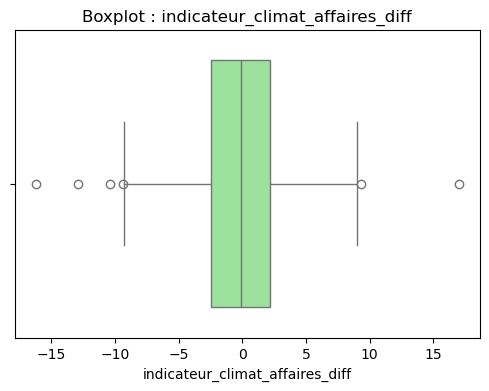

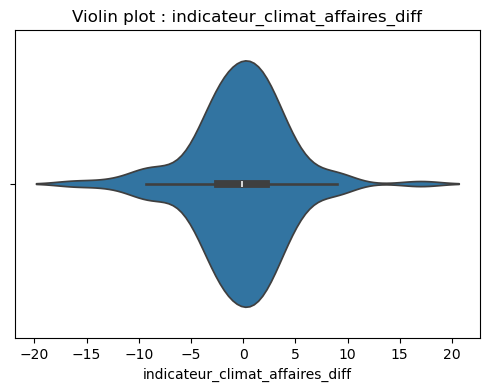

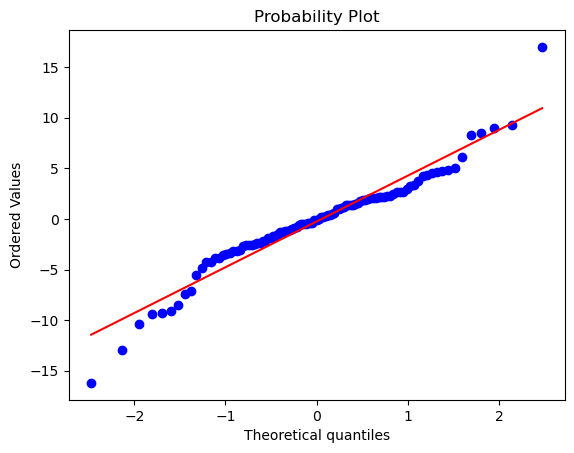

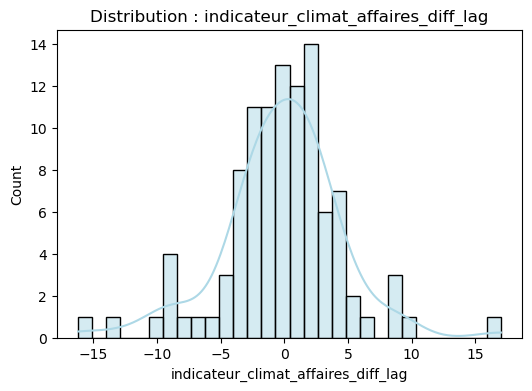

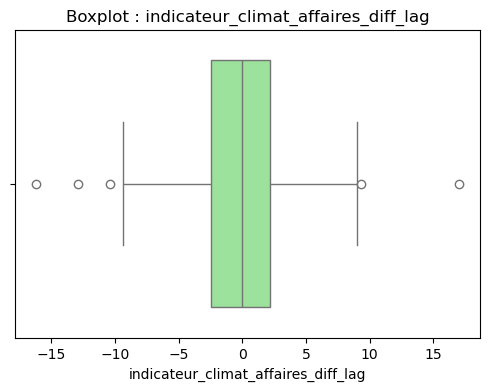

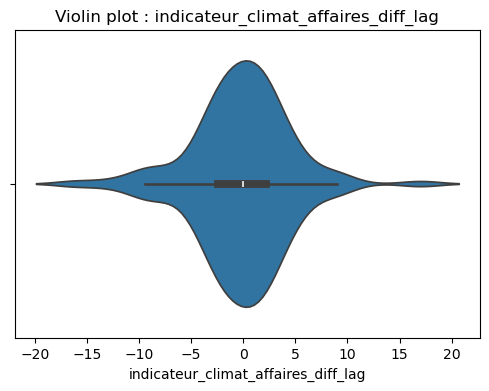

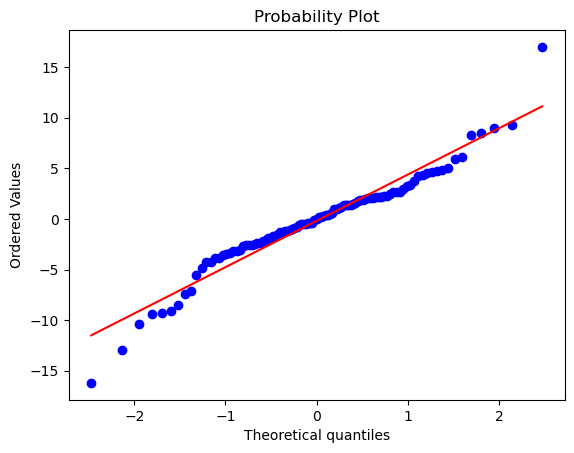

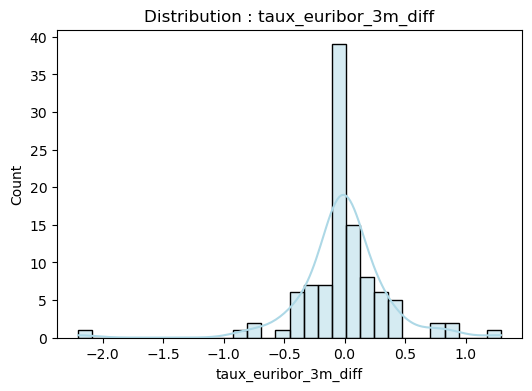

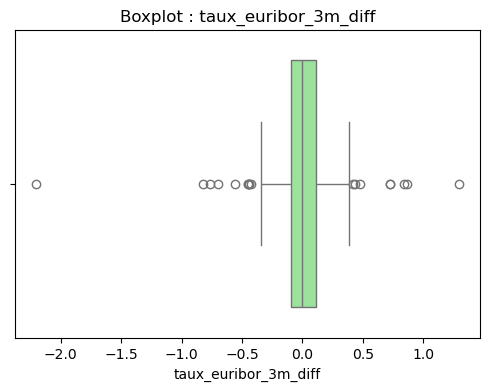

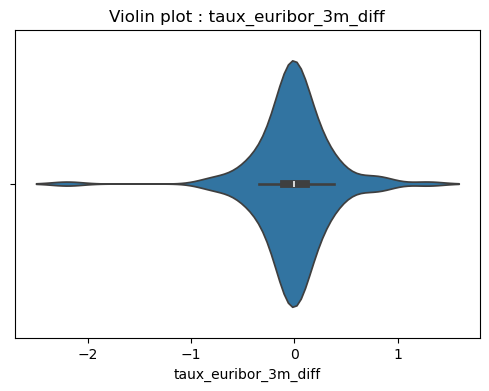

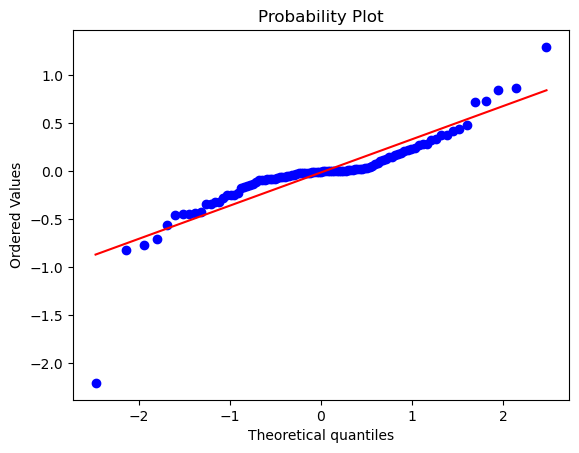

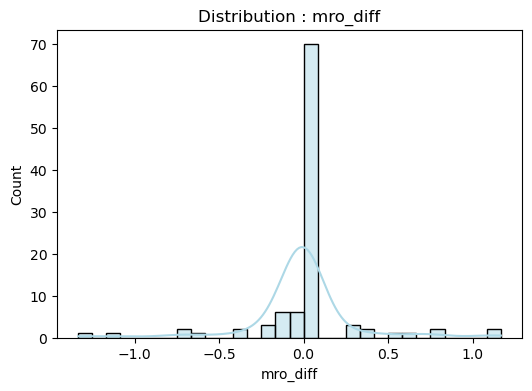

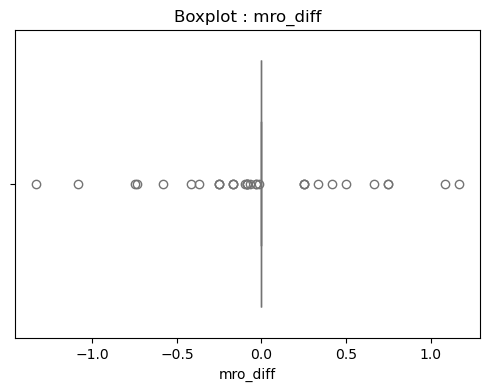

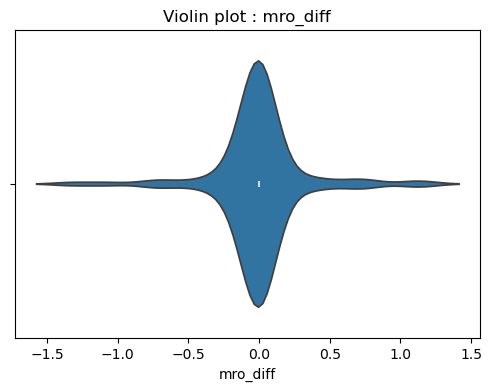

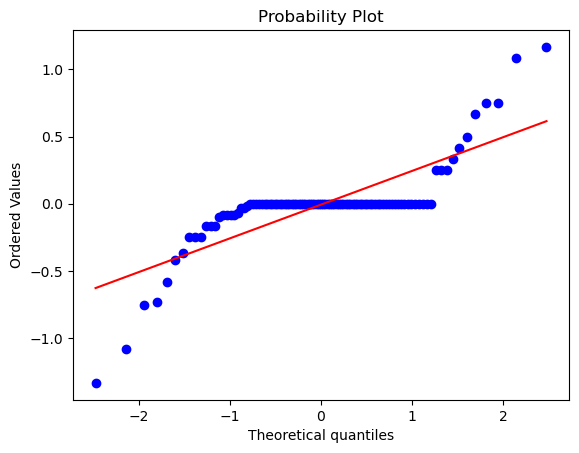

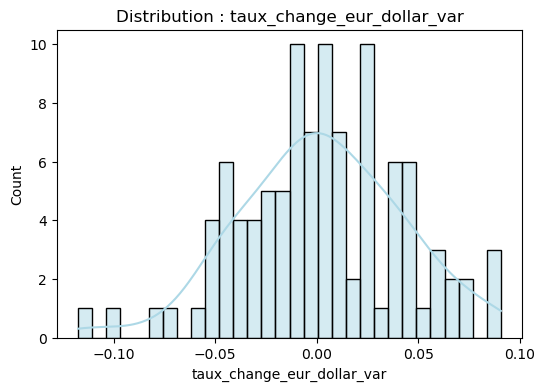

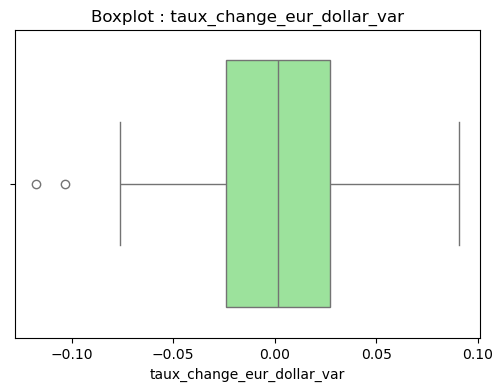

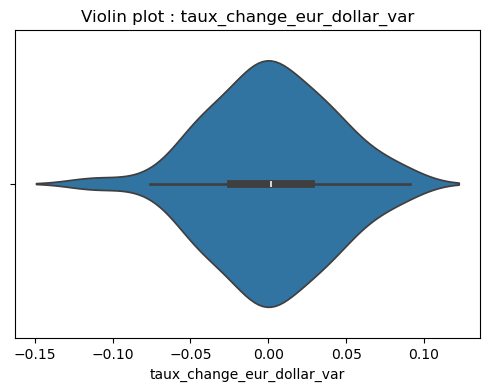

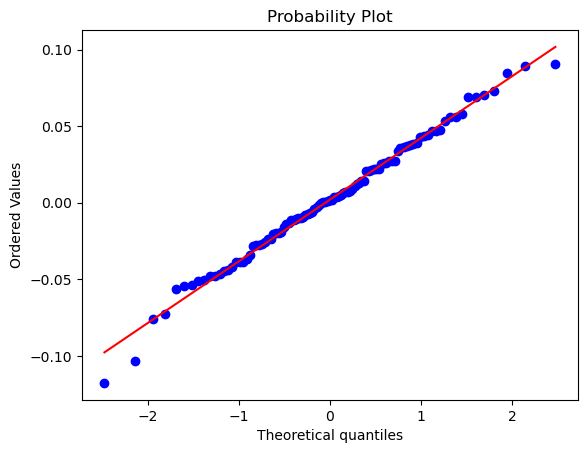

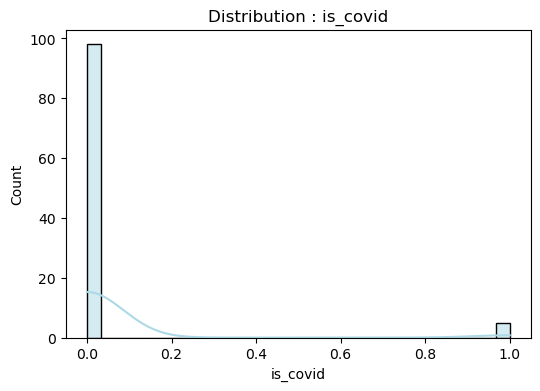

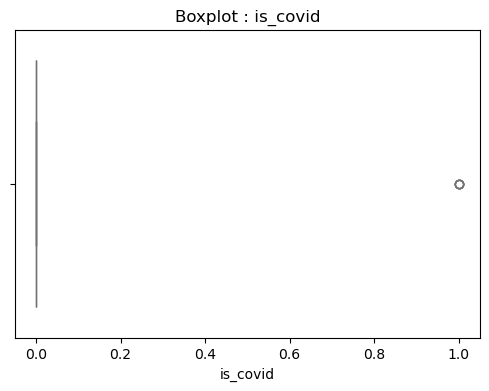

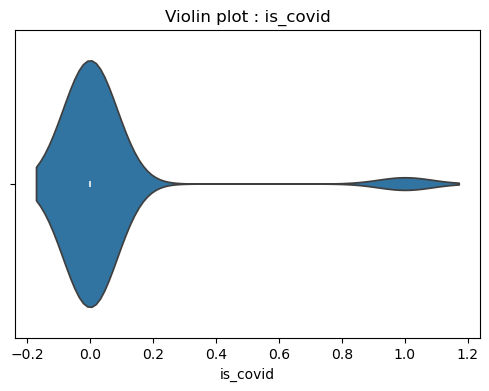

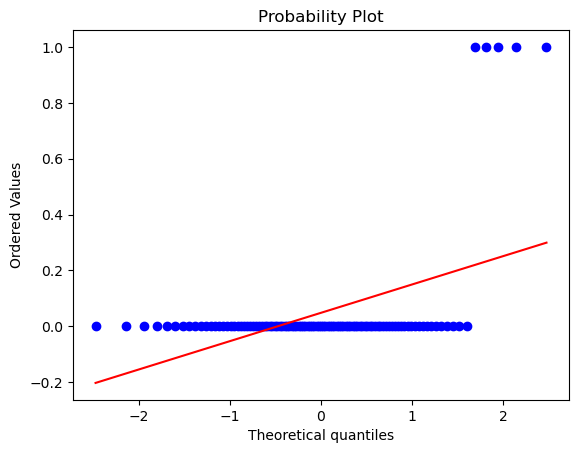

In [38]:
# Analyse univariée
# Histogramme - Boxplot - Violin plot

for col in num_cols:
    # Histogramme
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins= 30, color = "lightblue", kde=True)
    plt.title(f"Distribution : {col}")
    plt.show()
    
    # Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color = "lightgreen") 
    plt.title(f"Boxplot : {col}")
    plt.show()
    
    # Violin plot
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df[col])
    plt.title(f"Violin plot : {col}")
    plt.show()
    
    ## QQPLot
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.show()

# Création de dossier et sauvegarde des graphiques

import os
import re

BASE_PLOT_DIR = "eda_plots"
SUBDIRS = ["01_hist", "02_boxplot", "03_violin", "04_QQPlot"]

for sd in SUBDIRS:
    os.makedirs(os.path.join(BASE_PLOT_DIR, sd), exist_ok=True)

def safe_filename(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_.-]+", "_", name)

def save_fig(subdir: str, filename: str, dpi: int = 160):
    path = os.path.join(BASE_PLOT_DIR, subdir, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()
    return path

In [39]:
# Corrélation avec la variable dépendante

TARGET = "taux_chomage_total_insee"
corr = df[num_cols].corr()

corr_target = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_target.head(25))

taux_chomage_25_49_insee           0.985755
taux_chomage_ocde                  0.952564
taux_chomage_homme_insee           0.931717
taux_chomage_15_24_insee           0.895139
taux_chomage_femme_insee           0.884236
taux_chomage_50_plus_insee         0.819563
demandeur_femme_abcd_moins25       0.708352
demandeur_total_abcd_moins25       0.644496
isj                               -0.619890
ipc                               -0.596794
demandeur_homme_abcd_moins25       0.576233
taux_euribor_3m                   -0.531130
mro                               -0.495278
nb_interimaires                   -0.479583
nb_offres_france_travail          -0.472499
nb_defaillances_entreprise         0.377723
demandeur_homme_abcd_2549          0.317529
taux_change_eur_dollar             0.305948
indicateur_climat_affaires_diff    0.294724
population_active_var             -0.285755
indicateur_climat_emploi_diff      0.272670
ict_var                           -0.255614
demandeur_total_abcd_2549       

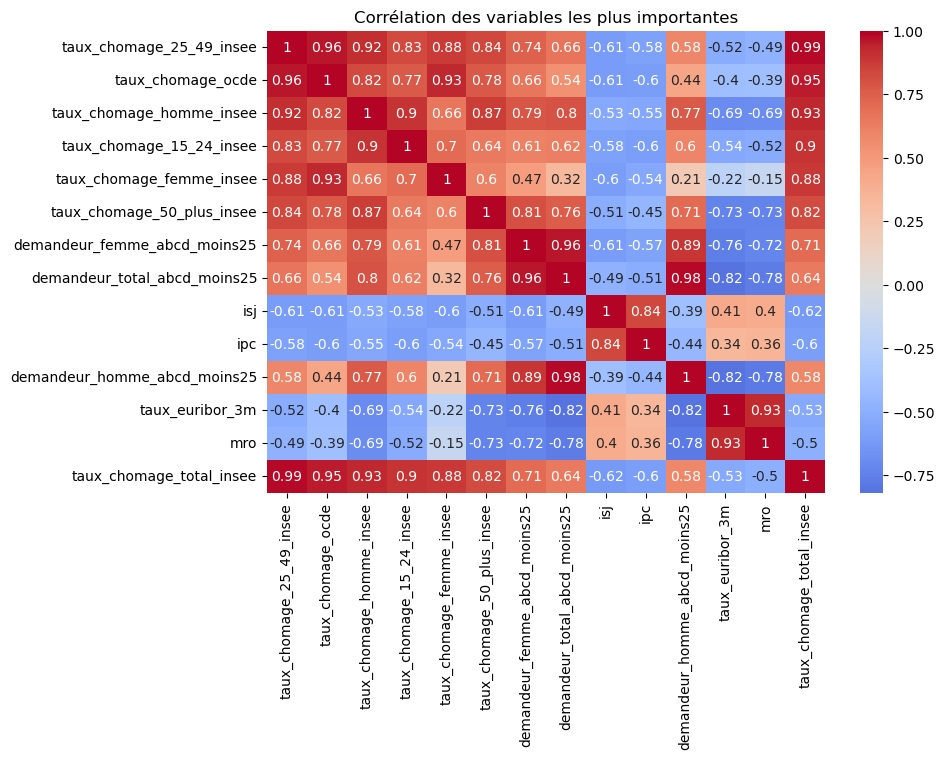

In [107]:
top_vars = corr_target.head(13).index.tolist()
corr_subset = df[top_vars + [TARGET]].corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélation des variables les plus importantes")
plt.show()

In [111]:
plt.savefig("C:/Users/jehov/Documents/Cours/UTT/9mars/graphiques/heatmap_corr.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [113]:
# Statistiques descriptives

display(df[num_cols].describe())

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,1.030000e+02,1.030000e+02,1.030000e+02,103.000000,...,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,8.678641,8.480583,8.903883,21.717476,7.857282,5.615534,4.761751e+06,2.285973e+06,2.475779e+06,716825.242718,...,0.067040,0.143207,-0.308233,-0.229126,-0.243689,-0.185437,-0.013769,-0.006634,0.002054,0.048544
std,0.994066,1.180649,0.999796,3.199768,0.935425,0.767445,9.346950e+05,4.965842e+05,4.445468e+05,79514.584577,...,0.937755,0.997494,4.140644,5.491895,4.605020,4.644634,0.380054,0.310556,0.039885,0.215963
min,7.100000,6.500000,6.800000,16.500000,6.300000,4.100000,3.245200e+06,1.499000e+06,1.746200e+06,550800.000000,...,-3.268628,-3.339930,-10.631357,-29.200000,-16.200000,-16.200000,-2.202967,-1.333333,-0.117539,0.000000
25%,7.800000,7.550000,8.050000,19.000000,7.200000,5.050000,3.890100e+06,1.806800e+06,2.073700e+06,661750.000000,...,-0.500155,-0.470794,-2.659974,-2.100000,-2.450000,-2.450000,-0.096517,0.000000,-0.023886,0.000000
50%,8.800000,8.200000,9.200000,21.800000,7.900000,5.500000,4.882500e+06,2.400400e+06,2.482100e+06,722700.000000,...,0.181477,0.197794,-0.222131,-0.100000,-0.100000,0.000000,-0.004667,0.000000,0.001803,0.000000
75%,9.300000,9.250000,9.700000,24.650000,8.400000,6.250000,5.699600e+06,2.767350e+06,2.885750e+06,782650.000000,...,0.721539,0.861117,2.530401,2.150000,2.150000,2.200000,0.108667,0.000000,0.027262,0.000000
max,10.500000,11.000000,10.400000,27.900000,9.700000,7.200000,6.107200e+06,2.968900e+06,3.138300e+06,866800.000000,...,1.901287,1.977185,8.887986,23.200000,17.000000,17.000000,1.291400,1.166667,0.090650,1.000000


#### Machine Learning

In [116]:
# Variables à exclure

LEAKY = {
    "date",
    TARGET,
    "taux_chomage_homme_insee",
    "taux_chomage_ocde"
    "taux_chomage_femme_insee",
    "taux_chomage_15_24_insee",
    "taux_chomage_25_49_insee",
    "taux_chomage_50_plus_insee",
    "demandeur_total_abcd_total",
    "demandeur_homme_abcd_total",
    "demandeur_femme_abcd_total",
    "demandeur_total_abcd_moins25",
    "demandeur_total_abcd_2549",
    "demandeur_total_abcd_plus50",
    "demandeur_homme_abcd_moins25",
    "demandeur_homme_abcd_2549",
    "demandeur_homme_abcd_plus50",
    "demandeur_femme_abcd_moins25",
    "demandeur_femme_abcd_2549",
    "demandeur_femme_abcd_plus50"
}

features = [c for c in num_cols if c not in LEAKY]
print("Nb features ML:", len(features))

Nb features ML: 41


In [118]:
# Séparation des données en train/test

X = df[features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, shuffle=False)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Garder les dates pour les plots
dates = df["date"]
dates_train, dates_test = train_test_split(dates, test_size=0.20, shuffle=False)

print("Période train:", dates_train.min(), "->", dates_train.max())
print("Période test :", dates_test.min(), "->", dates_test.max())

Train: (82, 41) Test: (21, 41)
Période train: 2000-01-01 00:00:00 -> 2020-04-01 00:00:00
Période test : 2020-07-01 00:00:00 -> 2025-07-01 00:00:00


#### Métriques

In [121]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred))
    }

rmse_scorer = make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False)

#### Entraînement des modèles

In [124]:
models = {
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.05, max_iter=20000))
    ]),
    "ElasticNet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=20000))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=800, random_state=0))
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=0))
    ])
}

In [126]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(name)

    if hasattr(model.named_steps["model"], "coef_"):

        values = model.named_steps["model"].coef_
        col = "coefficient"

    elif hasattr(model.named_steps["model"], "feature_importances_"):

        values = model.named_steps["model"].feature_importances_
        col = "importance"

    else:
        print("Pas de coefficients disponibles")
        continue

    df_imp = pd.DataFrame({
        "variable": X_train.columns,
        col: values
    }).sort_values(by=col, key=abs, ascending=False)

    display(df_imp)

LinearRegression


,variable,coefficient
1,population_active,0.664333
11,taux_chomage_ocde,0.516710
6,mro,0.327431
4,nb_interimaires,-0.203590
5,taux_euribor_3m,-0.198189
0,taux_chomage_femme_insee,0.156143
28,taux_chomage_total_insee_diff,0.124305
3,ict,-0.118568
15,indicateur_climat_affaires,0.113249
31,indicateur_climat_affaires_zscore,0.113249


Ridge


,variable,coefficient
11,taux_chomage_ocde,0.391711
0,taux_chomage_femme_insee,0.304263
1,population_active,0.213311
6,mro,0.177553
4,nb_interimaires,-0.114239
5,taux_euribor_3m,-0.105387
2,pib,0.101379
3,ict,0.088702
28,taux_chomage_total_insee_diff,0.082212
29,taux_chomage_ocde_diff,-0.073365


Lasso


...

,variable,coefficient
11,taux_chomage_ocde,0.384194
0,taux_chomage_femme_insee,0.309223
1,population_active,0.205664
5,taux_euribor_3m,-0.057640
8,ipc,-0.034106
14,indicateur_confiance_menage,-0.033176
30,indicateur_confiance_menage_zscore,-0.031879
7,taux_change_eur_dollar,0.027383
34,indicateur_climat_emploi_diff,0.017752
12,nb_defaillances_entreprise,0.013269


RandomForest


,variable,importance
11,taux_chomage_ocde,0.784287
5,taux_euribor_3m,0.040778
13,nb_offres_france_travail,0.031054
0,taux_chomage_femme_insee,0.026515
10,ipc_energie_only,0.013493
7,taux_change_eur_dollar,0.010188
37,taux_euribor_3m_diff,0.007111
30,indicateur_confiance_menage_zscore,0.006948
17,indicateur_retournement_conjoncturel,0.006599
14,indicateur_confiance_menage,0.006445


GradientBoosting


,variable,importance
11,taux_chomage_ocde,8.049310e-01
0,taux_chomage_femme_insee,3.644977e-02
5,taux_euribor_3m,3.465898e-02
30,indicateur_confiance_menage_zscore,1.992544e-02
7,taux_change_eur_dollar,1.685025e-02
1,population_active,1.458982e-02
13,nb_offres_france_travail,1.070197e-02
3,ict,1.031927e-02
14,indicateur_confiance_menage,8.915115e-03
24,ipc_yoy,7.276259e-03


#### Evaluation de la performance de chaque modèle

In [128]:
rows = []

for name, model in models.items():

    # entraînement
    model.fit(X_train, y_train)

    # prédictions
    pred_test = model.predict(X_test)

    # évaluation
    hold = evaluate(y_test, pred_test)

    rows.append({
        "model": name,
        "Test_RMSE": hold["RMSE"],
        "Test_MAE": hold["MAE"],
        "Test_R2": hold["R2"]
    })

results = pd.DataFrame(rows).sort_values("Test_RMSE")

display(results)

,model,Test_RMSE,Test_MAE,Test_R2
5,GradientBoosting,0.215227,0.168554,0.755466
3,ElasticNet,0.330674,0.318114,0.422777
4,RandomForest,0.355761,0.311923,0.331872
2,Lasso,0.455308,0.435060,-0.094346
1,Ridge,0.505060,0.442594,-0.346573
0,LinearRegression,0.931897,0.912820,-3.584373


#### Modèle Ridge avec GridSearch CV

In [132]:
ridge_pipe = models["Ridge"]
param_grid_ridge = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

gs_ridge = GridSearchCV(
    ridge_pipe,
    param_grid_ridge,
    scoring=rmse_scorer,
    n_jobs=-1
)
gs_ridge.fit(X_train, y_train)

print("Best Ridge params:", gs_ridge.best_params_)
print("Best CV RMSE:", -gs_ridge.best_score_)

pred = gs_ridge.predict(X_test)
print("Test metrics Ridge tuned:", evaluate(y_test, pred))

Best Ridge params: {'model__alpha': 0.1}
Best CV RMSE: 0.22585822109367748
Test metrics Ridge tuned: {'MAE': 0.756337002944327, 'RMSE': 0.7886439427586692, 'R2': -2.283265949083352}


#### Modèle GradientBoosting avec hyperparamètres

In [134]:
gbr_pipe = models["GradientBoosting"]
param_grid_gbr = {
    "model__n_estimators": [200, 400, 800],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gs_gbr = GridSearchCV(
    gbr_pipe,
    param_grid_gbr,
    scoring=rmse_scorer,
    n_jobs=-1
)
gs_gbr.fit(X_train, y_train)

print("Best GBR params:", gs_gbr.best_params_)
print("Best CV RMSE:", -gs_gbr.best_score_)

pred = gs_gbr.predict(X_test)
print("Test metrics GBR tuned:", evaluate(y_test, pred))

Best GBR params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 800}
Best CV RMSE: 0.5712569950343467
Test metrics GBR tuned: {'MAE': 0.15441832880597717, 'RMSE': 0.200724736661261, 'R2': 0.7873105676405306}


#### Choix du meilleur modèle

In [136]:
best_model = gs_gbr.best_estimator_
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)
print("Final test metrics:", evaluate(y_test, pred))

Final test metrics: {'MAE': 0.15441832880597717, 'RMSE': 0.200724736661261, 'R2': 0.7873105676405306}


#### Prédiction

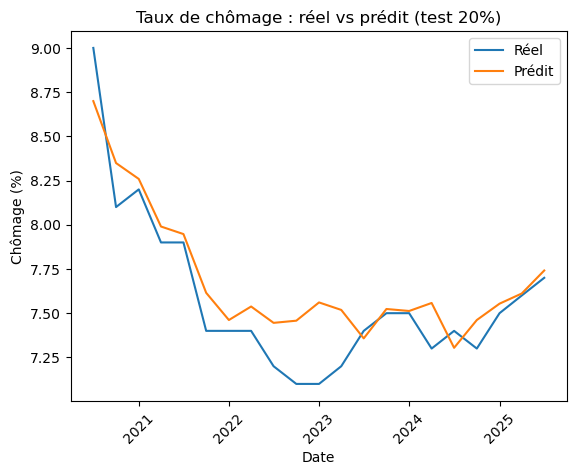

In [139]:
plt.figure()
plt.plot(dates_test.values, y_test.values, label= "Réel")
plt.plot(dates_test.values, pred, label= "Prédit")
plt.title("Taux de chômage : réel vs prédit (test 20%)")
plt.xlabel("Date")
plt.ylabel("Chômage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.show()